# Encoder and Random Forest and larger datasets

So far we have been limiting ourselves to single subsets of the data. A specfic instrument, ionization mode and what not. In this case I want to take several datasets, train them with different encoders then use a union of the outputs to train a much larger Random forest (ideally balaning that RF).

## Import packages

In [160]:
# Import packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests

# from fcd_torch import FCD
import torch

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.decomposition import PCA

from fcd_torch import FCD
import rdkit

import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import functions_enc as f

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter

## Globally used Functions

In [161]:
# Spectrum string to dataframe function
def spectrum_string_to_dataframe(df, spectrum_col, smiles_col):
    """
    Converts a DataFrame with a spectrum column (string of 'x:y' pairs) into a matrix
    where columns are unique x values, rows are spectra (even for duplicate SMILES), and values are y (intensity).
    The index will match the original DataFrame.
    """
    # Collect all unique x values (m/z)
    x_values_set = set()
    spectra_list = []
    for idx, row in df.iterrows():
        spectrum = row[spectrum_col]
        pairs = spectrum.split()
        xys = []
        for pair in pairs:
            try:
                x, y = pair.split(":") # Split into x and y
                #x = float(x.replace("'", "").replace('"', '')) # Remove quotes and convert to float (done in processing)
                #y = float(y.replace("'", "").replace('"', '')) # Remove quotes and convert to float (done in processing)
                xys.append((x, y))
                x_values_set.add(x)
            except Exception:
                continue
        spectra_list.append((row[smiles_col], dict(xys)))
    x_values = sorted(x_values_set) # Sort the x values to maintain order
    
    # Build the matrix
    matrix = []
    smiles_list = []
    for smiles, xy_dict in spectra_list:
        row = [xy_dict.get(x, 0.0) for x in x_values]
        matrix.append(row)
        smiles_list.append(smiles)
    df_matrix = pd.DataFrame(matrix, columns=[x for x in x_values]) # columns=[f"mz_{x}" for x in x_values]) to make stings
    df_matrix.insert(0, smiles_col, smiles_list)
    df_matrix.index = df.index  # preserve original row order/index
    return df_matrix

In [162]:
# Binning functions
# Binning the spectra data 
def bin_spectra_by_integer_mz(df):
    """
    Bins the spectra data by rounding m/z (column names) to the nearest integer,
    then sums intensities for duplicate integer bins.
    Assumes first column is SMILES, rest are m/z columns (floats).
    """
    smiles_col = df.columns[0]
    spectra = df.iloc[:, 1:]
    # Map each column to its integer bin
    int_mz = [int(round(float(c))) for c in spectra.columns]
    spectra.columns = int_mz
    # Group columns by integer m/z and sum
    binned = spectra.groupby(level=0, axis=1).sum()
    # Add the SMILES column back
    binned.insert(0, smiles_col, df[smiles_col])
    return binned

# Fill in the missing integer columns 
def fill_missing_integer_columns(df):
    """
    Ensures all integer columns from 1 to the maximum are present in the DataFrame.
    Missing columns are filled with zeros.
    Assumes the first column is the label (e.g., SMILES).
    """
    # Get the integer columns (skip the first column)
    int_cols = [col for col in df.columns[1:] if isinstance(col, int)]
    #min_col = min(int_cols)
    max_col = max(int_cols)
    all_int_cols = list(range(1, max_col + 1))
    # Find missing columns
    missing_cols = set(all_int_cols) - set(int_cols)
    # Add missing columns with zeros
    for col in missing_cols:
        df[col] = 0.0
    # Reorder columns: first column, then sorted integer columns
    ordered_cols = [df.columns[0]] + sorted(all_int_cols)
    df = df[ordered_cols]
    return df

In [163]:
# Cate's smiles to ChemNet embedding code
def get_chemnet_emb_from_smiles(smiles_list):
    """
    Get ChemNet embeddings from a list of SMILES strings.

    Parameters:
    smiles_list (list): List of SMILES strings.

    Returns:
    dict: A dictionary mapping each SMILES string to its corresponding ChemNet embedding.
    """
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    fcd = FCD(device, n_jobs=1)
    
    smiles_emb_dict = {}

    for smiles in smiles_list:
        try:
            emb = fcd.get_predictions([smiles])[0]
            smiles_emb_dict[smiles] = list(emb)
        except KeyError as e:
            if e == 'PropertyTable':
                smiles_emb_dict[smiles] = 'unknown'

    return smiles_emb_dict

In [164]:
def create_dataset_tensors(spectra_dataset, embedding_df, device, start_idx=None, stop_idx=None):
    """
    Create tensors from the provided spectra dataset and embedding DataFrame.

    Parameters:
    ----------
    spectra_dataset : pd.DataFrame
        DataFrame containing spectral data and chemical labels. Assumes specific 
        columns for processing based on the `carl` flag.

    embedding_df : pd.DataFrame
        DataFrame containing embeddings for chemicals, with 'Embedding Floats' 
        column corresponding to ChemNet embeddings.

    device : torch.device
        The device (CPU or GPU) on which to store the tensors.

    carl : bool, optional
        If True, processes the dataset assuming it has a different structure 
        (specifically without an 'Unnamed: 0' column). Default is False.

    Returns:
    -------
    tuple
        A tuple containing:
        - embeddings_tensor (torch.Tensor): Tensor of true embeddings for the chemicals.
        - spectra_tensor (torch.Tensor): Tensor of spectral data.
        - chem_encodings_tensor (torch.Tensor): Tensor of chemical name encodings.
        - spectra_indices_tensor (torch.Tensor): Tensor of indices corresponding to the spectra.
    """
    spectra = spectra_dataset.iloc[:,1:-1]

    #chem_encodings = spectra_dataset.iloc[:,-8:]

    # create tensors of spectra, true embeddings, and chemical name encodings for train and val
    chem_labels = list(spectra_dataset['SMILES_spectra'])
    embeddings_tensor = torch.Tensor([embedding_df.loc[embedding_df['SMILES'] == chem_name].iloc[0, 1:].values.astype(float) for chem_name in chem_labels]).to(device)
    spectra_tensor = torch.Tensor(spectra.values).to(device)
    #chem_encodings_tensor = torch.Tensor(chem_encodings.values).to(device)
    spectra_indices_tensor = torch.Tensor(spectra_dataset['index'].to_numpy()).to(device)

    return embeddings_tensor, spectra_tensor, spectra_indices_tensor #, chem_encodings_tensor

In [165]:
# Define a function to assign EPA levels
def assign_epa_level(response):
    if response <= 50:
        return "EPA_level_1"
    elif response <= 500:
        return "EPA_level_2"
    elif response <= 5000:
        return "EPA_level_3"
    else:
        return "EPA_level_4"


## Data Processing: Upload, Edits, and Split

In [166]:
# The 5/20 dataset with rat based toxicity data
df3 = pd.read_csv("/home/dlipsey/Research/MITLincolnLabs/MIT_LL_data/MIT_LL_data3.csv")
print(df3.shape)
df3.head()


# Uniformity of ionization model labels
print(df3["Ionization_Mode"].unique())
df3["Ionization_Mode"] = df3["Ionization_Mode"].replace("'Positive'", "'positive'")
print(df3["Ionization_Mode"].unique())

# Remove the N/A values in Ionization_Mode
df3 = df3[df3["Ionization_Mode"] != "'NaN'"]
print(df3["Ionization_Mode"].unique())

# Removing the '' from the SMILES
# Remove single quotes from all string columns in df3
df3 = df3.applymap(lambda x: x.replace("'", "") if isinstance(x, str) else x)
#df3["SMILES_spectra"] = df3["SMILES_spectra"].str.replace("'", "")

# Data split based on the 'Group' column
df3_QQpos = df3[df3['Group'] == 'Q-Orbitrap-positive'] # 1307
df3_QQneg = df3[df3['Group'] == 'Q-Orbitrap-negative'] # 756
df3_QTOFpos = df3[df3['Group'] == 'Q-TOF-positive'] # 736  
df3_LTQOpos = df3[df3['Group'] == 'LTQ-Orbitrap-positive'] # 481 

# With these there may not be enough data to train a model
df3_QQQpos = df3[df3['Group'] == 'QQQ-positive'] # 253
df3_QTOFneg = df3[df3['Group'] == 'Q-TOF-negative'] # 188
df3_QQQneg = df3[df3['Group'] == 'QQQ-negative'] # 85
df3_Opos = df3[df3['Group'] == 'Other-positive'] # 71
df3_LTQOneg = df3[df3['Group'] == 'LTQ-Orbitrap-negative'] # 63
df3_LTQpos = df3[df3['Group'] == 'LTQ-positive'] # 19
df3_QQQnan = df3[df3['Group'] == 'QQQ-nan'] # 18
df3_Oneg = df3[df3['Group'] == 'Other-negative'] # 13
df3_LTQneg = df3[df3['Group'] == 'LTQ-negative'] # 11

(4001, 16)
["'positive'" "'negative'" "'Positive'" "'NaN'"]
["'positive'" "'negative'" "'NaN'"]
["'positive'" "'negative'"]


In [167]:
# Find SMILES_spectra with more than 5 spectra in each dataset

def smiles_with_more_than_n(df, n=5, smiles_col='SMILES_spectra'):
    counts = df[smiles_col].value_counts()
    return counts[counts > n].index.tolist()

smiles_gt5_QQpos = smiles_with_more_than_n(df3_QQpos, n=5)
smiles_gt5_QQneg = smiles_with_more_than_n(df3_QQneg, n=5)
smiles_gt5_QTOFpos = smiles_with_more_than_n(df3_QTOFpos, n=5)
smiles_gt5_LTQOpos = smiles_with_more_than_n(df3_LTQOpos, n=5)

print("QQpos:", smiles_gt5_QQpos)
print("QQneg:", smiles_gt5_QQneg)
print("QTOFpos:", smiles_gt5_QTOFpos)
print("LTQOpos:", smiles_gt5_LTQOpos)

QQpos: ['CN1N(C(=O)C=C1C)C1=CC=CC=C1', 'OCC(O)C(O)C(O)CO', 'CC1=C(C)N=C(NS(=O)(=O)C2=CC=C(N)C=C2)O1', 'CCN(CC)CCNC(=O)C1=CC(Cl)=C(N)C=C1OC', 'CNCCCN1C2=C(CCC3=C1C=CC=C3)C=CC=C2', 'OCC(O)C(O)C(O)C(O)CO', 'CCCCCCCC(=O)OCC(COC(=O)CCCCCCC)OC(=O)CCCCCCC', 'O=C(O)CCCCCCCC(=O)O', 'CC(CN1CCN(CCOCCO)CC1)CN1C2=CC=CC=C2SC2=CC=CC=C12', 'CC[C@@H](CO)NCCN[C@@H](CC)CO', 'CN(C)CCC=C1C2=CC=CC=C2CSC2=C1C=CC=C2', 'CN(CC1(C)CCCO1)S(=O)(=O)C1=CC=C(Cl)C(=C1)S(N)(=O)=O', 'CN1C2=C(N(CCO)C=N2)C(=O)N(C)C1=O', 'C=C(C)C1CC=C(C)CC1', 'CCCOC(=O)NCCCN(C)C', 'CC1=CC(=O)OC2=C1C=CC(O)=C2', 'COCCOCCOCCOCCOC', 'S=C1NCCN1', 'CN(C)C(=S)SSC(=S)N(C)C', 'CCCSP(=O)(OCC)SCCC', 'CCOC(=O)C1=CC=C(N)C=C1', 'CCCCOCCOP(=O)(OCCOCCCC)OCCOCCCC', 'CCSC(=O)N1CCCCCC1', 'CCOP(=S)(OCC)SCSP(=S)(OCC)OCC', 'CC(C)C1=NC(=O)C=C(C)N1', 'COC1=C(C=C(Cl)C=C1)C(=O)NCCC1=CC=C(C=C1)S(=O)(=O)NC(=O)NC1CCCCC1', 'CCN(CC)C1=CC=C2C(C)=CC(=O)OC2=C1', 'CC(C)(OC1=CC=C(CCNC(=O)C2=CC=C(Cl)C=C2)C=C1)C(O)=O', 'CN(C)C1=CC=C(SC#N)C=C1', 'CC(=O)N1CCN(CC1)C1=CC=C(OC[C@H]

In [168]:
def find_smiles_examples_min5(df, smiles_col='SMILES_spectra', response_col='Response', min_count=5):
    # Only keep SMILES with at least min_count examples
    counts = df[smiles_col].value_counts()
    valid_smiles = counts[counts >= min_count].index
    df = df[df[smiles_col].isin(valid_smiles)]
    # 1 with response <= 50
    cat1 = df[df[response_col] <= 50].drop_duplicates(subset=smiles_col).head(1)
    # 2 with response <= 500 but > 50
    cat2 = df[(df[response_col] > 50) & (df[response_col] <= 500)].drop_duplicates(subset=smiles_col).head(2)
    # 2 with response <= 5000 but > 500
    cat3 = df[(df[response_col] > 500) & (df[response_col] <= 5000)].drop_duplicates(subset=smiles_col).head(2)
    # 1 with response > 5000
    cat4 = df[df[response_col] > 5000].drop_duplicates(subset=smiles_col).head(1)
    # Concatenate results
    result = pd.concat([cat1, cat2, cat3, cat4])
    return result[[smiles_col, response_col]]

#print("QQpos examples (min 5):")
#print(find_smiles_examples_min5(df3_QQpos))

print("\nQQneg examples (min 5):")
print(find_smiles_examples_min5(df3_QQneg))

print("\nQTOFpos examples (min 5):")
print(find_smiles_examples_min5(df3_QTOFpos))

print("\nLTQOpos examples (min 5):")
print(find_smiles_examples_min5(df3_LTQOpos))


QQneg examples (min 5):
                                         SMILES_spectra  Response
2923                                 NC(=S)NC1=CC=CC=C1       3.0
235        CC(C)(C)C1=CC(=CC(=C1O)C(C)(C)C)[N+]([O-])=O     250.0
248                         CC(C)(C)C1=CC=C(C=C1)C(O)=O     473.0
6                        C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1    5000.0
88                      CC(=C)C(=O)NC1=CC=C(Cl)C(Cl)=C1    1800.0
284   CC(C)(C1=CC(Cl)=C(O)C(Cl)=C1)C1=CC(Cl)=C(O)C(C...    7432.0

QTOFpos examples (min 5):
                                        SMILES_spectra     Response
927       CCC(=O)N(C1CCN(CCC2=CC=CC=C2)CC1)C1=CC=CC=C1    18.000000
139  CC(=O)N1CCN(CC1)C1=CC=C(OC[C@H]2CO[C@@](CN3C=C...   166.000000
227          CC(C)(C)C(=O)C(OC1=CC=C(Cl)C=C1)N1C=CN=C1   400.000000
30   C1=CN(C=N1)C(C1=CC=CC=C1)C1=CC=C(C=C1)C1=CC=CC=C1  1463.000000
200                               CC(=O)OCC[N+](C)(C)C  2498.419317
158         CC(=O)NC1=CC=C(C=C1)S(=O)(=O)NC1=NOC(C)=C1  8400.000000

LTQOpos e

In [169]:
# Get SMILES lists for each group
qqpos_smiles = find_smiles_examples_min5(df3_QQpos)['SMILES_spectra'].tolist()
qqneg_smiles = find_smiles_examples_min5(df3_QQneg)['SMILES_spectra'].tolist()
qtofpos_smiles = find_smiles_examples_min5(df3_QTOFpos)['SMILES_spectra'].tolist()
ltqopos_smiles = find_smiles_examples_min5(df3_LTQOpos)['SMILES_spectra'].tolist()

# Combine all into one list
all_smiles = qqpos_smiles + qqneg_smiles + qtofpos_smiles + ltqopos_smiles

print("All selected SMILES:")
print(all_smiles)

All selected SMILES:
['CCCSP(=O)(OCC)SCCC', 'C#CCN(C)Cc1ccccc1', 'C1=CC(=CC=N1)C1=CC=NC=C1', 'C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1', 'C(NC1=NC=NC2=C1N=CN2C1CCCCO1)C1=CC=CC=C1', 'CC(C)N(CC1=CC=CC=C1)C(=O)C(C)(C)C', 'NC(=S)NC1=CC=CC=C1', 'CC(C)(C)C1=CC(=CC(=C1O)C(C)(C)C)[N+]([O-])=O', 'CC(C)(C)C1=CC=C(C=C1)C(O)=O', 'C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1', 'CC(=C)C(=O)NC1=CC=C(Cl)C(Cl)=C1', 'CC(C)(C1=CC(Cl)=C(O)C(Cl)=C1)C1=CC(Cl)=C(O)C(Cl)=C1', 'CCC(=O)N(C1CCN(CCC2=CC=CC=C2)CC1)C1=CC=CC=C1', 'CC(=O)N1CCN(CC1)C1=CC=C(OC[C@H]2CO[C@@](CN3C=CN=C3)(O2)C2=CC=C(Cl)C=C2Cl)C=C1', 'CC(C)(C)C(=O)C(OC1=CC=C(Cl)C=C1)N1C=CN=C1', 'C1=CN(C=N1)C(C1=CC=CC=C1)C1=CC=C(C=C1)C1=CC=CC=C1', 'CC(=O)OCC[N+](C)(C)C', 'CC(=O)NC1=CC=C(C=C1)S(=O)(=O)NC1=NOC(C)=C1', 'C1CCC(CC1)NC1CCCCC1', 'CC(CN1CCN(CCOCCO)CC1)CN1C2=CC=CC=C2SC2=CC=CC=C12', 'CC(=O)OCC(COC(C)=O)OC(C)=O', 'CC(C)N(C(=O)CCl)c1ccccc1', 'CC1=C(C)N=C(NS(=O)(=O)C2=CC=C(N)C=C2)O1']


## Data Processing: Binning

In [170]:
df3_QQpos_matrix = spectrum_string_to_dataframe(df3_QQpos,'Spectrum', 'SMILES_spectra')
df3_QQpos_spectra = df3_QQpos_matrix
df3_QQneg_matrix = spectrum_string_to_dataframe(df3_QQneg,'Spectrum', 'SMILES_spectra')
df3_QQneg_spectra = df3_QQneg_matrix
df3_QTOFpos_matrix = spectrum_string_to_dataframe(df3_QTOFpos,'Spectrum', 'SMILES_spectra')
df3_QTOFpos_spectra = df3_QTOFpos_matrix
df3_LTQOpos_matrix = spectrum_string_to_dataframe(df3_LTQOpos,'Spectrum', 'SMILES_spectra')
df3_LTQOpos_spectra = df3_LTQOpos_matrix

In [171]:
# Processing of the spectra to enable binning to work (consider changing this to a function)

# Conversion of m/z values to floats, keeping the first column (SMIELS) as is
# For df3_QQpos_spectra
cols = df3_QQpos_spectra.columns.tolist()
new_cols = [cols[0]] + [float(c) for c in cols[1:]]
df3_QQpos_spectra.columns = new_cols

# For df3_QQneg_spectra
cols = df3_QQneg_spectra.columns.tolist()
new_cols = [cols[0]] + [float(c) for c in cols[1:]]
df3_QQneg_spectra.columns = new_cols

# For df3_QTOFpos_spectra
cols = df3_QTOFpos_spectra.columns.tolist()
new_cols = [cols[0]] + [float(c) for c in cols[1:]]
df3_QTOFpos_spectra.columns = new_cols

# For df3_LTQOpos_spectra
cols = df3_LTQOpos_spectra.columns.tolist()
new_cols = [cols[0]] + [float(c) for c in cols[1:]]
df3_LTQOpos_spectra.columns = new_cols


# Convert all elements except the first column to float
df3_QQpos_spectra.iloc[:, 1:] = df3_QQpos_spectra.iloc[:, 1:].apply(pd.to_numeric, errors='coerce')
df3_QQneg_spectra.iloc[:, 1:] = df3_QQneg_spectra.iloc[:, 1:].apply(pd.to_numeric, errors='coerce')
df3_QTOFpos_spectra.iloc[:, 1:] = df3_QTOFpos_spectra.iloc[:, 1:].apply(pd.to_numeric, errors='coerce')
df3_LTQOpos_spectra.iloc[:, 1:] = df3_LTQOpos_spectra.iloc[:, 1:].apply(pd.to_numeric, errors='coerce')

all_float = all(isinstance(c, float) for c in df3_QQneg_spectra.columns[1:])
print("All columns are float:", all_float)
all_float = all(isinstance(c, float) for c in df3_QQpos_spectra.columns[1:])
print("All columns are float:", all_float)
all_float = all(isinstance(c, float) for c in df3_QTOFpos_spectra.columns[1:])
print("All columns are float:", all_float)
all_float = all(isinstance(c, float) for c in df3_LTQOpos_spectra.columns[1:])
print("All columns are float:", all_float)

# Check if every element is a float
spectra = df3_QQpos_spectra.iloc[:, 1:]
all_float_elements = spectra.applymap(lambda x: isinstance(x, float)).all().all()
print("All elements are float:", all_float_elements)
spectra = df3_QQneg_spectra.iloc[:, 1:]
all_float_elements = spectra.applymap(lambda x: isinstance(x, float)).all().all()
print("All elements are float:", all_float_elements)
spectra = df3_QTOFpos_spectra.iloc[:, 1:]
all_float_elements = spectra.applymap(lambda x: isinstance(x, float)).all().all()
print("All elements are float:", all_float_elements)
spectra = df3_LTQOpos_spectra.iloc[:, 1:]
all_float_elements = spectra.applymap(lambda x: isinstance(x, float)).all().all()
print("All elements are float:", all_float_elements)

# Sort columns by float value, keep the first column (SMILES) first
cols = df3_QQpos_spectra.columns.tolist()
sorted_cols = [cols[0]] + sorted(cols[1:], key=float)
df3_QQpos_spectra = df3_QQpos_spectra[sorted_cols]
cols = df3_QQneg_spectra.columns.tolist()
sorted_cols = [cols[0]] + sorted(cols[1:], key=float)
df3_QQneg_spectra = df3_QQneg_spectra[sorted_cols]
cols = df3_QTOFpos_spectra.columns.tolist()
sorted_cols = [cols[0]] + sorted(cols[1:], key=float)
df3_QTOFpos_spectra = df3_QTOFpos_spectra[sorted_cols]
cols = df3_LTQOpos_spectra.columns.tolist()
sorted_cols = [cols[0]] + sorted(cols[1:], key=float)
df3_LTQOpos_spectra = df3_LTQOpos_spectra[sorted_cols]

All columns are float: True
All columns are float: True
All columns are float: True
All columns are float: True
All elements are float: True
All elements are float: True
All elements are float: True
All elements are float: True


In [172]:
df3_QTOFpos_spectra.head()

,SMILES_spectra,29.0112,30.032,30.0323,31.01686,31.54035,38.5076,39.0214,39.0215,39.02194,...,1879.890381,1881.465942,1890.796509,1894.779541,1939.240845,1965.805054,1966.380615,1982.848389,2000.461914,2000.942627
30,C1=CN(C=N1)C(C1=CC=CC=C1)C1=CC=C(C=C1)C1=CC=CC=C1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
31,C1=CN(C=N1)C(C1=CC=CC=C1)C1=CC=C(C=C1)C1=CC=CC=C1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
32,C1=CN(C=N1)C(C1=CC=CC=C1)C1=CC=C(C=C1)C1=CC=CC=C1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
33,C1=CN(C=N1)C(C1=CC=CC=C1)C1=CC=C(C=C1)C1=CC=CC=C1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
34,C1=CN(C=N1)C(C1=CC=CC=C1)C1=CC=C(C=C1)C1=CC=CC=C1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [173]:
# Use the binning function 
# On df3_QQpos_spectra
binned_df3_QQpos_spectra = bin_spectra_by_integer_mz(df3_QQpos_spectra)
binned_df3_QQpos_spectra_filled = fill_missing_integer_columns(binned_df3_QQpos_spectra)

# On df3_QQpos_spectra
binned_df3_QQneg_spectra = bin_spectra_by_integer_mz(df3_QQneg_spectra)
binned_df3_QQneg_spectra_filled = fill_missing_integer_columns(binned_df3_QQneg_spectra)

# On df3_QQpos_spectra
binned_df3_QTOFpos_spectra = bin_spectra_by_integer_mz(df3_QTOFpos_spectra)
binned_df3_QTOFpos_spectra_filled = fill_missing_integer_columns(binned_df3_QTOFpos_spectra)

# On df3_LTQOpos_spectra
binned_df3_LTQOpos_spectra = bin_spectra_by_integer_mz(df3_LTQOpos_spectra)
binned_df3_LTQOpos_spectra_filled = fill_missing_integer_columns(binned_df3_LTQOpos_spectra)

/tmp/ipykernel_861924/339873635.py:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  binned.insert(0, smiles_col, df[smiles_col])
/tmp/ipykernel_861924/339873635.py:36: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[col] = 0.0
/tmp/ipykernel_861924/339873635.py:36: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = fra

In [174]:
print(binned_df3_QQpos_spectra_filled.shape)
print(binned_df3_QQneg_spectra_filled.shape)
print(binned_df3_QTOFpos_spectra_filled.shape)
print(binned_df3_LTQOpos_spectra_filled.shape)

(1307, 680)
(756, 493)
(736, 2002)
(481, 816)


In [175]:
# # Save the binned spectra to a CSV file
# binned_df3_QQpos_spectra_filled.to_csv("/home/dlipsey/Research/MITLincolnLabs/MIT_LL_data/binned_df3_QQpos_spectra.csv", index=False)
# binned_df3_QQneg_spectra_filled.to_csv("/home/dlipsey/Research/MITLincolnLabs/MIT_LL_data/binned_df3_QQneg_spectra.csv", index=False)
# binned_df3_QTOFpos_spectra_filled.to_csv("/home/dlipsey/Research/MITLincolnLabs/MIT_LL_data/binned_df3_QTOFpos_spectra.csv", index=False)
# binned_df3_LTQOpos_spectra_filled.to_csv("/home/dlipsey/Research/MITLincolnLabs/MIT_LL_data/binned_df3_LTQOpos_spectra.csv", index=False)

## ChemNet True Embeddings

In [176]:
ChemNet_of_df3_QQpos_no_repeats_dict = get_chemnet_emb_from_smiles(df3_QQpos_spectra["SMILES_spectra"])
ChemNet_of_df3_QQneg_no_repeats_dict = get_chemnet_emb_from_smiles(df3_QQneg_spectra["SMILES_spectra"])
ChemNet_of_df3_QTOFpos_no_repeats_dict = get_chemnet_emb_from_smiles(df3_QTOFpos_spectra["SMILES_spectra"])
ChemNet_of_df3_LTQOpos_no_repeats_dict = get_chemnet_emb_from_smiles(df3_LTQOpos_spectra["SMILES_spectra"])

/home/dlipsey/.local/lib/python3.8/site-packages/fcd_torch/fcd.py:51: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  keras_config = torch.load(model_path)


In [177]:
# Making the ChemNet embeddings into a dataframes
# For df3_QQpos
ChemNet_of_df3_QQpos_no_repeats = pd.DataFrame.from_dict(ChemNet_of_df3_QQpos_no_repeats_dict, orient='index')
ChemNet_of_df3_QQpos_no_repeats.reset_index(inplace=True)
ChemNet_of_df3_QQpos_no_repeats.rename(columns={'index': 'SMILES'}, inplace=True)

# For df3_QQneg
ChemNet_of_df3_QQneg_no_repeats = pd.DataFrame.from_dict(ChemNet_of_df3_QQneg_no_repeats_dict, orient='index')
ChemNet_of_df3_QQneg_no_repeats.reset_index(inplace=True)
ChemNet_of_df3_QQneg_no_repeats.rename(columns={'index': 'SMILES'}, inplace=True)

# For df3_QTOFpos
ChemNet_of_df3_QTOFpos_no_repeats = pd.DataFrame.from_dict(ChemNet_of_df3_QTOFpos_no_repeats_dict, orient='index')
ChemNet_of_df3_QTOFpos_no_repeats.reset_index(inplace=True)
ChemNet_of_df3_QTOFpos_no_repeats.rename(columns={'index': 'SMILES'}, inplace=True)

# For df3_LTQOpos
ChemNet_of_df3_LTQOpos_no_repeats = pd.DataFrame.from_dict(ChemNet_of_df3_LTQOpos_no_repeats_dict, orient='index')
ChemNet_of_df3_LTQOpos_no_repeats.reset_index(inplace=True)
ChemNet_of_df3_LTQOpos_no_repeats.rename(columns={'index': 'SMILES'}, inplace=True)

In [178]:
# # Save ChemNet embeddings to a CSV file
# ChemNet_of_df3_QQpos_no_repeats.to_csv("/home/dlipsey/Research/MITLincolnLabs/MIT_LL_data/ChemNet_of_df3_QQpos_no_repeats.csv", index=False)
# ChemNet_of_df3_QQneg_no_repeats.to_csv("/home/dlipsey/Research/MITLincolnLabs/MIT_LL_data/ChemNet_of_df3_QQneg_no_repeats.csv", index=False)
# ChemNet_of_df3_QTOFpos_no_repeats.to_csv("/home/dlipsey/Research/MITLincolnLabs/MIT_LL_data/ChemNet_of_df3_QTOFpos_no_repeats.csv", index=False)
# ChemNet_of_df3_LTQOpos_no_repeats.to_csv("/home/dlipsey/Research/MITLincolnLabs/MIT_LL_data/ChemNet_of_df3_LTQOpos_no_repeats.csv", index=False)

## Encoder Implementation

### Encoder architecture

In [179]:
batch_size = 64
epochs=500
lr=0.0001
criterion=nn.MSELoss()
output_size = 512
num_layers = 10

#%%
# Encoder architecture (With Validation Set)
class Encoder(nn.Module):
    def __init__(self, input_size, output_size, num_layers):
        super().__init__()
        layers = []
        layer_sizes = np.linspace(input_size, output_size, num_layers + 1, dtype=int)
        for i in range(num_layers):
            layers.append(nn.Linear(layer_sizes[i], layer_sizes[i+1]))
            if i < num_layers - 1:
                layers.append(nn.LeakyReLU(inplace=True))
        self.encoder = nn.Sequential(*layers)

    def forward(self, x):
        return self.encoder(x)

def train_model(model, train_data, val_data, epochs, learning_rate, criterion, device):
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for batch, true_embeddings, _ in train_data:
            batch = batch.to(device)
            true_embeddings = true_embeddings.to(device)

            optimizer.zero_grad()
            batch_predicted_embeddings = model(batch)
            loss = criterion(batch_predicted_embeddings, true_embeddings)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        average_train_loss = running_loss / len(train_loader)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for val_batch, val_true_embeddings, _ in val_data:
                val_batch = val_batch.to(device)
                val_true_embeddings = val_true_embeddings.to(device)

                val_batch_predicted_embeddings = model(val_batch)

                val_loss = criterion(val_batch_predicted_embeddings, val_true_embeddings)
                val_loss += loss.item()
        average_val_loss = val_loss / len(val_loader)

        print(f'Epoch [{epoch+1}/{epochs}]')
        print(f'   Training loss: {average_train_loss}')
        print(f'   Validation loss: {average_val_loss}')

    return model
#%%


## Implementation of the encoder on df3_QQpos

In [180]:
# Training and validation dataset split for the positive ionization mode
df3_QQpos_spectra= pd.read_csv("/home/dlipsey/Research/MITLincolnLabs/MIT_LL_data/binned_df3_QQpos_spectra.csv")
name_smiles_embedding_df = pd.read_csv("/home/dlipsey/Research/MITLincolnLabs/MIT_LL_data/ChemNet_of_df3_QQpos_no_repeats.csv")
# Generalize the syntax
dataset =  df3_QQpos_spectra

# Count occurrences of each SMILES_spectra and keep only SMILES_spectra with at least 4 entries
counts = dataset['SMILES_spectra'].value_counts()
valid_smiles = counts[counts >= 4].index
filtered_dataset = dataset[dataset['SMILES_spectra'].isin(valid_smiles)].copy()

train_indices = []
test_indices = []

for smiles, group in filtered_dataset.groupby('SMILES_spectra'):
    idx = group.index.tolist()
    n = len(idx)
    np.random.shuffle(idx)  # shuffle for randomness
    split = n // 2
    test_idx = idx[:split]
    train_idx = idx[split:]
    # If odd, train gets the extra
    train_indices.extend(train_idx)
    test_indices.extend(test_idx)

train_data = filtered_dataset.loc[train_indices].reset_index(drop=True)
test_data = filtered_dataset.loc[test_indices].reset_index(drop=True)

# Add an 'index' column 
train_data['index'] = train_data.index
test_data['index'] = test_data.index

print(train_data.shape)
print(test_data.shape)

# Make a copy
train_data_df3_QQpos = train_data.copy()

# Make a copy
train_data_df3_QQpos = train_data.copy()
test_data_df3_QQpos = test_data.copy()
# Load val_data
val_data = test_data

# # train_data = pd.read_csv("/") 
# # val_data = pd.read_csv(" ") 



(609, 681)
(579, 681)


In [181]:
# Remove the specified SMILES from the train and test sets,
# and collect them into a new DataFrame called super_testing_df3_QQpos

smiles_to_remove = ['CCCSP(=O)(OCC)SCCC', 'C#CCN(C)Cc1ccccc1', 'C1=CC(=CC=N1)C1=CC=NC=C1', 'C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1', 
                    'C(NC1=NC=NC2=C1N=CN2C1CCCCO1)C1=CC=CC=C1', 'CC(C)N(CC1=CC=CC=C1)C(=O)C(C)(C)C', 'NC(=S)NC1=CC=CC=C1', 
                    'CC(C)(C)C1=CC(=CC(=C1O)C(C)(C)C)[N+]([O-])=O', 'CC(C)(C)C1=CC=C(C=C1)C(O)=O', 'C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1', 
                    'CC(=C)C(=O)NC1=CC=C(Cl)C(Cl)=C1', 'CC(C)(C1=CC(Cl)=C(O)C(Cl)=C1)C1=CC(Cl)=C(O)C(Cl)=C1', 
                    'CCC(=O)N(C1CCN(CCC2=CC=CC=C2)CC1)C1=CC=CC=C1', 'CC(=O)N1CCN(CC1)C1=CC=C(OC[C@H]2CO[C@@](CN3C=CN=C3)(O2)C2=CC=C(Cl)C=C2Cl)C=C1', 
                    'CC(C)(C)C(=O)C(OC1=CC=C(Cl)C=C1)N1C=CN=C1', 'C1=CN(C=N1)C(C1=CC=CC=C1)C1=CC=C(C=C1)C1=CC=CC=C1', 'CC(=O)OCC[N+](C)(C)C', 
                    'CC(=O)NC1=CC=C(C=C1)S(=O)(=O)NC1=NOC(C)=C1', 'C1CCC(CC1)NC1CCCCC1', 'CC(CN1CCN(CCOCCO)CC1)CN1C2=CC=CC=C2SC2=CC=CC=C12', 
                    'CC(=O)OCC(COC(C)=O)OC(C)=O', 'CC(C)N(C(=O)CCl)c1ccccc1', 'CC1=C(C)N=C(NS(=O)(=O)C2=CC=C(N)C=C2)O1']

# Combine train and test to extract all rows with those SMILES
combined_df3_QQpos = pd.concat([train_data_df3_QQpos, test_data_df3_QQpos], ignore_index=True)
super_testing_df3_QQpos = combined_df3_QQpos[combined_df3_QQpos['SMILES_spectra'].isin(smiles_to_remove)].copy()

# Remove those SMILES from train and test sets
train_data_df3_QQpos = train_data_df3_QQpos[~train_data_df3_QQpos['SMILES_spectra'].isin(smiles_to_remove)].copy()
test_data_df3_QQpos = test_data_df3_QQpos[~test_data_df3_QQpos['SMILES_spectra'].isin(smiles_to_remove)].copy()

print("After removal, train shape:", train_data_df3_QQpos.shape)
print("After removal, test shape:", test_data_df3_QQpos.shape)
print("Super testing set shape:", super_testing_df3_QQpos.shape)
print("Any left in train?", any(train_data_df3_QQpos['SMILES_spectra'].isin(smiles_to_remove)))
print("Any left in test?", any(test_data_df3_QQpos['SMILES_spectra'].isin(smiles_to_remove)))

After removal, train shape: (564, 681)
After removal, test shape: (538, 681)
Super testing set shape: (86, 681)
Any left in train? False
Any left in test? False


In [182]:
# # Verification of the number of trianing and testing SMILES present
# print(train_data_df3_QQpos["SMILES_spectra"].nunique())
# print(test_data_df3_QQpos["SMILES_spectra"].nunique())
# # Limitation of the number of training and testing spectra used
# num_smiles_limit = 10  # Change this value to use a different number of SMILES
# unique_smiles = train_data_df3_QQpos['SMILES_spectra'].unique()[:num_smiles_limit]
# train_data_df3_QQpos = train_data_df3_QQpos[train_data_df3_QQpos['SMILES_spectra'].isin(unique_smiles)].copy()
# test_data_df3_QQpos = test_data_df3_QQpos[test_data_df3_QQpos['SMILES_spectra'].isin(unique_smiles)].copy()
# # Verify the limitation
# print(train_data_df3_QQpos["SMILES_spectra"].nunique())
# print(test_data_df3_QQpos["SMILES_spectra"].nunique())

In [183]:
# Ensure we match the data correctly:
train_data = train_data_df3_QQpos
test_data = test_data_df3_QQpos
val_data = test_data

In [184]:
# Encoder training
device = f.set_up_gpu()
# device = torch.device('cpu')

# Training set
y_train, x_train, train_indices_tensor = create_dataset_tensors(
    train_data, name_smiles_embedding_df, device, start_idx=2, stop_idx=-0)
#sorted_chem_names = list(train_data.columns[-8:])
del train_data

# Validation set
y_val, x_val, val_indices_tensor = create_dataset_tensors(
    val_data, name_smiles_embedding_df, device, start_idx=2, stop_idx=-0)
del val_data

train_data = TensorDataset(x_train, y_train, train_indices_tensor)
val_data = TensorDataset(x_val, y_val, val_indices_tensor)
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)
#%%
encoder_df3_QQpos = Encoder(input_size=x_train.shape[1], output_size=output_size, num_layers=num_layers).to(device)

#%%
model_df3_QQpos = train_model(
    model=encoder_df3_QQpos,
    train_data=train_loader,
    val_data=val_loader,
    epochs=epochs,
    learning_rate=lr,
    criterion=criterion,
    device=device
)
x_val_df3_QQpos = x_val
x_train_df3_QQpos = x_train

Selected GPU ID: 1
  Name: NVIDIA GeForce RTX 4090
  Memory Free: 22796.0 MB
  Memory Used: 1421.0 MB
  GPU Load: 0.00%
Current device ID:  cuda:1
PyTorch current device ID: 1
PyTorch current device name: NVIDIA GeForce RTX 4090
Epoch [1/500]
   Training loss: 0.08826007694005966
   Validation loss: 0.019066408276557922
Epoch [2/500]
   Training loss: 0.08119729989104801
   Validation loss: 0.017055394127964973
Epoch [3/500]
   Training loss: 0.0716937788658672
   Validation loss: 0.015314057469367981
Epoch [4/500]
   Training loss: 0.06610843125316831
   Validation loss: 0.014596815221011639
Epoch [5/500]
   Training loss: 0.06392317679193285
   Validation loss: 0.013923048973083496
Epoch [6/500]
   Training loss: 0.06343588978052139
   Validation loss: 0.014040322974324226
Epoch [7/500]
   Training loss: 0.06320467591285706
   Validation loss: 0.01419993955641985
Epoch [8/500]
   Training loss: 0.06304682542880376
   Validation loss: 0.014303524978458881
Epoch [9/500]
   Training los

## Implementation of the encoder on df3_QQneg

In [185]:
# Training and validation dataset split 
df3_QQneg_spectra= pd.read_csv("/home/dlipsey/Research/MITLincolnLabs/MIT_LL_data/binned_df3_QQneg_spectra.csv")
name_smiles_embedding_df = pd.read_csv("/home/dlipsey/Research/MITLincolnLabs/MIT_LL_data/ChemNet_of_df3_QQneg_no_repeats.csv")

# Generalize the syntax
dataset =  df3_QQneg_spectra

# Count occurrences of each SMILES_spectra and keep only SMILES_spectra with at least 4 entries
counts = dataset['SMILES_spectra'].value_counts()
valid_smiles = counts[counts >= 4].index
filtered_dataset = dataset[dataset['SMILES_spectra'].isin(valid_smiles)].copy()

train_indices = []
test_indices = []

for smiles, group in filtered_dataset.groupby('SMILES_spectra'):
    idx = group.index.tolist()
    n = len(idx)
    np.random.shuffle(idx)  # shuffle for randomness
    split = n // 2
    test_idx = idx[:split]
    train_idx = idx[split:]
    # If odd, train gets the extra
    train_indices.extend(train_idx)
    test_indices.extend(test_idx)

train_data = filtered_dataset.loc[train_indices].reset_index(drop=True)
test_data = filtered_dataset.loc[test_indices].reset_index(drop=True)

# Add an 'index' column 
train_data['index'] = train_data.index
test_data['index'] = test_data.index

print(train_data.shape)
print(test_data.shape)

# Make a copy
train_data_df3_QQneg = train_data.copy()

# Make a copy
train_data_df3_QQneg = train_data.copy()
test_data_df3_QQneg = test_data.copy()
# Load val_data 
val_data = test_data

# # train_data = pd.read_csv("/") 
# # val_data = pd.read_csv(" ") 

(359, 494)
(342, 494)


In [186]:
# Remove the specified SMILES from the train and test sets,
# and collect them into a new DataFrame called super_testing_df3_QQpos

smiles_to_remove = ['CCCSP(=O)(OCC)SCCC', 'C#CCN(C)Cc1ccccc1', 'C1=CC(=CC=N1)C1=CC=NC=C1', 'C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1', 
                    'C(NC1=NC=NC2=C1N=CN2C1CCCCO1)C1=CC=CC=C1', 'CC(C)N(CC1=CC=CC=C1)C(=O)C(C)(C)C', 'NC(=S)NC1=CC=CC=C1', 
                    'CC(C)(C)C1=CC(=CC(=C1O)C(C)(C)C)[N+]([O-])=O', 'CC(C)(C)C1=CC=C(C=C1)C(O)=O', 'C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1', 
                    'CC(=C)C(=O)NC1=CC=C(Cl)C(Cl)=C1', 'CC(C)(C1=CC(Cl)=C(O)C(Cl)=C1)C1=CC(Cl)=C(O)C(Cl)=C1', 
                    'CCC(=O)N(C1CCN(CCC2=CC=CC=C2)CC1)C1=CC=CC=C1', 'CC(=O)N1CCN(CC1)C1=CC=C(OC[C@H]2CO[C@@](CN3C=CN=C3)(O2)C2=CC=C(Cl)C=C2Cl)C=C1', 
                    'CC(C)(C)C(=O)C(OC1=CC=C(Cl)C=C1)N1C=CN=C1', 'C1=CN(C=N1)C(C1=CC=CC=C1)C1=CC=C(C=C1)C1=CC=CC=C1', 'CC(=O)OCC[N+](C)(C)C', 
                    'CC(=O)NC1=CC=C(C=C1)S(=O)(=O)NC1=NOC(C)=C1', 'C1CCC(CC1)NC1CCCCC1', 'CC(CN1CCN(CCOCCO)CC1)CN1C2=CC=CC=C2SC2=CC=CC=C12', 
                    'CC(=O)OCC(COC(C)=O)OC(C)=O', 'CC(C)N(C(=O)CCl)c1ccccc1', 'CC1=C(C)N=C(NS(=O)(=O)C2=CC=C(N)C=C2)O1']

# Combine train and test to extract all rows with those SMILES
combined_df3_QQneg = pd.concat([train_data_df3_QQneg, test_data_df3_QQneg], ignore_index=True)
super_testing_df3_QQneg = combined_df3_QQneg[combined_df3_QQneg['SMILES_spectra'].isin(smiles_to_remove)].copy()

# Remove those SMILES from train and test sets
train_data_df3_QQneg = train_data_df3_QQneg[~train_data_df3_QQneg['SMILES_spectra'].isin(smiles_to_remove)].copy()
test_data_df3_QQneg = test_data_df3_QQneg[~test_data_df3_QQneg['SMILES_spectra'].isin(smiles_to_remove)].copy()

print("After removal, train shape:", train_data_df3_QQneg.shape)
print("After removal, test shape:", test_data_df3_QQneg.shape)
print("Super testing set shape:", super_testing_df3_QQneg.shape)
print("Any left in train?", any(train_data_df3_QQneg['SMILES_spectra'].isin(smiles_to_remove)))
print("Any left in test?", any(test_data_df3_QQneg['SMILES_spectra'].isin(smiles_to_remove)))

After removal, train shape: (341, 494)
After removal, test shape: (324, 494)
Super testing set shape: (36, 494)
Any left in train? False
Any left in test? False


In [187]:
# # Verification of the number of trianing and testing SMILES present
# print(train_data_df3_QQneg["SMILES_spectra"].nunique())
# print(test_data_df3_QQneg["SMILES_spectra"].nunique())
# # Limitation of the number of training and testing spectra used
# num_smiles_limit = 10  # Change this value to use a different number of SMILES
# unique_smiles = train_data_df3_QQneg['SMILES_spectra'].unique()[:num_smiles_limit]
# train_data_df3_QQneg = train_data_df3_QQneg[train_data_df3_QQneg['SMILES_spectra'].isin(unique_smiles)].copy()
# test_data_df3_QQneg = test_data_df3_QQneg[test_data_df3_QQneg['SMILES_spectra'].isin(unique_smiles)].copy()
# # Verify the limitation
# print(train_data_df3_QQneg["SMILES_spectra"].nunique())
# print(test_data_df3_QQneg["SMILES_spectra"].nunique())

In [188]:
# Ensure we match the data correctly:
train_data = train_data_df3_QQneg
test_data = test_data_df3_QQneg
val_data = test_data

In [189]:
# Encoder training
device = f.set_up_gpu()
# device = torch.device('cpu')

# Training set
y_train, x_train, train_indices_tensor = create_dataset_tensors(
    train_data, name_smiles_embedding_df, device, start_idx=2, stop_idx=-0)
#sorted_chem_names = list(train_data.columns[-8:])
del train_data

# Validation set
y_val, x_val, val_indices_tensor = create_dataset_tensors(
    val_data, name_smiles_embedding_df, device, start_idx=2, stop_idx=-0)
del val_data

train_data = TensorDataset(x_train, y_train, train_indices_tensor)
val_data = TensorDataset(x_val, y_val, val_indices_tensor)
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)
#%%
encoder_df3_QQneg = Encoder(input_size=x_train.shape[1], output_size=output_size, num_layers=num_layers).to(device)

#%%
model_df3_QQneg = train_model(
    model=encoder_df3_QQneg,
    train_data=train_loader,
    val_data=val_loader,
    epochs=epochs,
    learning_rate=lr,
    criterion=criterion,
    device=device
)
x_val_df3_QQneg = x_val
x_train_df3_QQneg = x_train

Selected GPU ID: 1
  Name: NVIDIA GeForce RTX 4090
  Memory Free: 22796.0 MB
  Memory Used: 1421.0 MB
  GPU Load: 2.00%
Current device ID:  cuda:1
PyTorch current device ID: 1
PyTorch current device name: NVIDIA GeForce RTX 4090
Epoch [1/500]
   Training loss: 0.09085627769430478
   Validation loss: 0.03190338611602783
Epoch [2/500]
   Training loss: 0.0901012954612573
   Validation loss: 0.032959502190351486
Epoch [3/500]
   Training loss: 0.08441706870992978
   Validation loss: 0.029314979910850525
Epoch [4/500]
   Training loss: 0.07668894032637279
   Validation loss: 0.027513820677995682
Epoch [5/500]
   Training loss: 0.0710959533850352
   Validation loss: 0.02629697136580944
Epoch [6/500]
   Training loss: 0.06674390782912572
   Validation loss: 0.024530228227376938
Epoch [7/500]
   Training loss: 0.06309556278089683
   Validation loss: 0.022097360342741013
Epoch [8/500]
   Training loss: 0.06148533895611763
   Validation loss: 0.021212395280599594
Epoch [9/500]
   Training loss:

## Implementation of the encoder on df3_QTOFpos

In [190]:
# Training and validation dataset split 
df3_QTOFpos_spectra= pd.read_csv("/home/dlipsey/Research/MITLincolnLabs/MIT_LL_data/binned_df3_QTOFpos_spectra.csv")
name_smiles_embedding_df = pd.read_csv("/home/dlipsey/Research/MITLincolnLabs/MIT_LL_data/ChemNet_of_df3_QTOFpos_no_repeats.csv")

# Generalize the syntax
dataset =  df3_QTOFpos_spectra

# Count occurrences of each SMILES_spectra and keep only SMILES_spectra with at least 4 entries
counts = dataset['SMILES_spectra'].value_counts()
valid_smiles = counts[counts >= 4].index
filtered_dataset = dataset[dataset['SMILES_spectra'].isin(valid_smiles)].copy()

train_indices = []
test_indices = []

for smiles, group in filtered_dataset.groupby('SMILES_spectra'):
    idx = group.index.tolist()
    n = len(idx)
    np.random.shuffle(idx)  # shuffle for randomness
    split = n // 2
    test_idx = idx[:split]
    train_idx = idx[split:]
    # If odd, train gets the extra
    train_indices.extend(train_idx)
    test_indices.extend(test_idx)

train_data = filtered_dataset.loc[train_indices].reset_index(drop=True)
test_data = filtered_dataset.loc[test_indices].reset_index(drop=True)

# Add an 'index' column 
train_data['index'] = train_data.index
test_data['index'] = test_data.index

print(train_data.shape)
print(test_data.shape)

# Make a copy
train_data_df3_QQneg = train_data.copy()

# Make a copy
train_data_df3_QTOFpos = train_data.copy()
test_data_df3_QTOFpos = test_data.copy() 
# Load val_data
val_data = test_data

# # train_data = pd.read_csv("/") 
# # val_data = pd.read_csv(" ") 


(330, 2003)
(308, 2003)


In [191]:
# Remove the specified SMILES from the train and test sets,
# and collect them into a new DataFrame called super_testing_df3_QQpos

smiles_to_remove = ['CCCSP(=O)(OCC)SCCC', 'C#CCN(C)Cc1ccccc1', 'C1=CC(=CC=N1)C1=CC=NC=C1', 'C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1', 
                    'C(NC1=NC=NC2=C1N=CN2C1CCCCO1)C1=CC=CC=C1', 'CC(C)N(CC1=CC=CC=C1)C(=O)C(C)(C)C', 'NC(=S)NC1=CC=CC=C1', 
                    'CC(C)(C)C1=CC(=CC(=C1O)C(C)(C)C)[N+]([O-])=O', 'CC(C)(C)C1=CC=C(C=C1)C(O)=O', 'C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1', 
                    'CC(=C)C(=O)NC1=CC=C(Cl)C(Cl)=C1', 'CC(C)(C1=CC(Cl)=C(O)C(Cl)=C1)C1=CC(Cl)=C(O)C(Cl)=C1', 
                    'CCC(=O)N(C1CCN(CCC2=CC=CC=C2)CC1)C1=CC=CC=C1', 'CC(=O)N1CCN(CC1)C1=CC=C(OC[C@H]2CO[C@@](CN3C=CN=C3)(O2)C2=CC=C(Cl)C=C2Cl)C=C1', 
                    'CC(C)(C)C(=O)C(OC1=CC=C(Cl)C=C1)N1C=CN=C1', 'C1=CN(C=N1)C(C1=CC=CC=C1)C1=CC=C(C=C1)C1=CC=CC=C1', 'CC(=O)OCC[N+](C)(C)C', 
                    'CC(=O)NC1=CC=C(C=C1)S(=O)(=O)NC1=NOC(C)=C1', 'C1CCC(CC1)NC1CCCCC1', 'CC(CN1CCN(CCOCCO)CC1)CN1C2=CC=CC=C2SC2=CC=CC=C12', 
                    'CC(=O)OCC(COC(C)=O)OC(C)=O', 'CC(C)N(C(=O)CCl)c1ccccc1', 'CC1=C(C)N=C(NS(=O)(=O)C2=CC=C(N)C=C2)O1']

# Combine train and test to extract all rows with those SMILES
combined_df3_QTOFpos = pd.concat([train_data_df3_QTOFpos, test_data_df3_QTOFpos], ignore_index=True)
super_testing_df3_QTOFpos = combined_df3_QTOFpos[combined_df3_QTOFpos['SMILES_spectra'].isin(smiles_to_remove)].copy()

# Remove those SMILES from train and test sets
train_data_df3_QTOFpos = train_data_df3_QTOFpos[~train_data_df3_QTOFpos['SMILES_spectra'].isin(smiles_to_remove)].copy()
test_data_df3_QTOFpos = test_data_df3_QTOFpos[~test_data_df3_QTOFpos['SMILES_spectra'].isin(smiles_to_remove)].copy()

print("After removal, train shape:", train_data_df3_QTOFpos.shape)
print("After removal, test shape:", test_data_df3_QTOFpos.shape)
print("Super testing set shape:", super_testing_df3_QTOFpos.shape)
print("Any left in train?", any(train_data_df3_QTOFpos['SMILES_spectra'].isin(smiles_to_remove)))
print("Any left in test?", any(test_data_df3_QTOFpos['SMILES_spectra'].isin(smiles_to_remove)))

After removal, train shape: (298, 2003)
After removal, test shape: (279, 2003)
Super testing set shape: (61, 2003)
Any left in train? False
Any left in test? False


In [192]:
# # Verification of the number of trianing and testing SMILES present
# print(train_data_df3_QTOFpos["SMILES_spectra"].nunique())
# print(test_data_df3_QTOFpos["SMILES_spectra"].nunique())
# # Limitation of the number of training and testing spectra used
# num_smiles_limit = 10  # Change this value to use a different number of SMILES
# unique_smiles = train_data_df3_QTOFpos['SMILES_spectra'].unique()[:num_smiles_limit]
# train_data_df3_QTOFpos = train_data_df3_QTOFpos[train_data_df3_QTOFpos['SMILES_spectra'].isin(unique_smiles)].copy()
# test_data_df3_QTOFpos = test_data_df3_QTOFpos[test_data_df3_QTOFpos['SMILES_spectra'].isin(unique_smiles)].copy()
# # Verify the limitation
# print(train_data_df3_QTOFpos["SMILES_spectra"].nunique())
# print(test_data_df3_QTOFpos["SMILES_spectra"].nunique())

In [193]:
# Ensure we match the data correctly:
train_data = train_data_df3_QTOFpos
test_data = test_data_df3_QTOFpos
val_data = test_data

In [194]:
# Encoder training
device = f.set_up_gpu()
# device = torch.device('cpu')

# Training set
y_train, x_train, train_indices_tensor = create_dataset_tensors(
    train_data, name_smiles_embedding_df, device, start_idx=2, stop_idx=-0)
#sorted_chem_names = list(train_data.columns[-8:])
del train_data

# Validation set
y_val, x_val, val_indices_tensor = create_dataset_tensors(
    val_data, name_smiles_embedding_df, device, start_idx=2, stop_idx=-0)
del val_data

train_data = TensorDataset(x_train, y_train, train_indices_tensor)
val_data = TensorDataset(x_val, y_val, val_indices_tensor)
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)
#%%
encoder_df3_QTOFpos = Encoder(input_size=x_train.shape[1], output_size=output_size, num_layers=num_layers).to(device)

#%%
model_df3_QTOFpos = train_model(
    model=encoder_df3_QTOFpos,
    train_data=train_loader,
    val_data=val_loader,
    epochs=epochs,
    learning_rate=lr,
    criterion=criterion,
    device=device
)
x_val_df3_QTOFpos = x_val
x_train_df3_QTOFpos = x_train

Selected GPU ID: 1
  Name: NVIDIA GeForce RTX 4090
  Memory Free: 22764.0 MB
  Memory Used: 1453.0 MB
  GPU Load: 1.00%
Current device ID:  cuda:1
PyTorch current device ID: 1
PyTorch current device name: NVIDIA GeForce RTX 4090
Epoch [1/500]
   Training loss: 0.08513161391019822
   Validation loss: 0.030760500580072403
Epoch [2/500]
   Training loss: 0.08104133754968643
   Validation loss: 0.02951032482087612
Epoch [3/500]
   Training loss: 0.0739314541220665
   Validation loss: 0.028019756078720093
Epoch [4/500]
   Training loss: 0.06769365072250366
   Validation loss: 0.025919808074831963
Epoch [5/500]
   Training loss: 0.06347660720348358
   Validation loss: 0.02401210553944111
Epoch [6/500]
   Training loss: 0.06130440756678581
   Validation loss: 0.023048153147101402
Epoch [7/500]
   Training loss: 0.06040919348597527
   Validation loss: 0.022785482928156853
Epoch [8/500]
   Training loss: 0.06016179174184799
   Validation loss: 0.023113315925002098
Epoch [9/500]
   Training loss

## Implementation of the encoder on df3_LTQOpos

In [195]:
# Training and validation dataset split 
df3_LTQOpos_spectra= pd.read_csv("/home/dlipsey/Research/MITLincolnLabs/MIT_LL_data/binned_df3_LTQOpos_spectra.csv")
name_smiles_embedding_df = pd.read_csv("/home/dlipsey/Research/MITLincolnLabs/MIT_LL_data/ChemNet_of_df3_LTQOpos_no_repeats.csv")

# Generalize the syntax
dataset = df3_LTQOpos_spectra

# Count occurrences of each SMILES_spectra and keep only SMILES_spectra with at least 4 entries
counts = dataset['SMILES_spectra'].value_counts()
valid_smiles = counts[counts >= 4].index
filtered_dataset = dataset[dataset['SMILES_spectra'].isin(valid_smiles)].copy()

train_indices = []
test_indices = []

for smiles, group in filtered_dataset.groupby('SMILES_spectra'):
    idx = group.index.tolist()
    n = len(idx)
    np.random.shuffle(idx)  # shuffle for randomness
    split = n // 2
    test_idx = idx[:split]
    train_idx = idx[split:]
    # If odd, train gets the extra
    train_indices.extend(train_idx)
    test_indices.extend(test_idx)

train_data = filtered_dataset.loc[train_indices].reset_index(drop=True)
test_data = filtered_dataset.loc[test_indices].reset_index(drop=True)

# Add an 'index' column 
train_data['index'] = train_data.index
test_data['index'] = test_data.index

print(train_data.shape)
print(test_data.shape)

# Make a copy
train_data_df3_LTQOpos = train_data.copy()
test_data_df3_LTQOpos = test_data.copy()
# Load val_data
val_data = test_data

# # train_data = pd.read_csv("/") 
# # val_data = pd.read_csv(" ") 


(239, 817)
(233, 817)


In [196]:
# Remove the specified SMILES from the train and test sets,
# and collect them into a new DataFrame called super_testing_df3_QQpos

smiles_to_remove = ['CCCSP(=O)(OCC)SCCC', 'C#CCN(C)Cc1ccccc1', 'C1=CC(=CC=N1)C1=CC=NC=C1', 'C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1', 
                    'C(NC1=NC=NC2=C1N=CN2C1CCCCO1)C1=CC=CC=C1', 'CC(C)N(CC1=CC=CC=C1)C(=O)C(C)(C)C', 'NC(=S)NC1=CC=CC=C1', 
                    'CC(C)(C)C1=CC(=CC(=C1O)C(C)(C)C)[N+]([O-])=O', 'CC(C)(C)C1=CC=C(C=C1)C(O)=O', 'C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1', 
                    'CC(=C)C(=O)NC1=CC=C(Cl)C(Cl)=C1', 'CC(C)(C1=CC(Cl)=C(O)C(Cl)=C1)C1=CC(Cl)=C(O)C(Cl)=C1', 
                    'CCC(=O)N(C1CCN(CCC2=CC=CC=C2)CC1)C1=CC=CC=C1', 'CC(=O)N1CCN(CC1)C1=CC=C(OC[C@H]2CO[C@@](CN3C=CN=C3)(O2)C2=CC=C(Cl)C=C2Cl)C=C1', 
                    'CC(C)(C)C(=O)C(OC1=CC=C(Cl)C=C1)N1C=CN=C1', 'C1=CN(C=N1)C(C1=CC=CC=C1)C1=CC=C(C=C1)C1=CC=CC=C1', 'CC(=O)OCC[N+](C)(C)C', 
                    'CC(=O)NC1=CC=C(C=C1)S(=O)(=O)NC1=NOC(C)=C1', 'C1CCC(CC1)NC1CCCCC1', 'CC(CN1CCN(CCOCCO)CC1)CN1C2=CC=CC=C2SC2=CC=CC=C12', 
                    'CC(=O)OCC(COC(C)=O)OC(C)=O', 'CC(C)N(C(=O)CCl)c1ccccc1', 'CC1=C(C)N=C(NS(=O)(=O)C2=CC=C(N)C=C2)O1']

# Combine train and test to extract all rows with those SMILES
combined_df3_LTQOpos = pd.concat([train_data_df3_LTQOpos, test_data_df3_LTQOpos], ignore_index=True)
super_testing_df3_LTQOpos = combined_df3_LTQOpos[combined_df3_LTQOpos['SMILES_spectra'].isin(smiles_to_remove)].copy()

# Remove those SMILES from train and test sets
train_data_df3_LTQOpos = train_data_df3_LTQOpos[~train_data_df3_LTQOpos['SMILES_spectra'].isin(smiles_to_remove)].copy()
test_data_df3_LTQOpos = test_data_df3_LTQOpos[~test_data_df3_LTQOpos['SMILES_spectra'].isin(smiles_to_remove)].copy()

print("After removal, train shape:", train_data_df3_LTQOpos.shape)
print("After removal, test shape:", test_data_df3_LTQOpos.shape)
print("Super testing set shape:", super_testing_df3_LTQOpos.shape)
print("Any left in train?", any(train_data_df3_LTQOpos['SMILES_spectra'].isin(smiles_to_remove)))
print("Any left in test?", any(test_data_df3_LTQOpos['SMILES_spectra'].isin(smiles_to_remove)))

After removal, train shape: (190, 817)
After removal, test shape: (186, 817)
Super testing set shape: (96, 817)
Any left in train? False
Any left in test? False


In [197]:
# # Verification of the number of trianing and testing SMILES present
# print(train_data_df3_LTQOpos["SMILES_spectra"].nunique())
# print(test_data_df3_LTQOpos["SMILES_spectra"].nunique())
# # Limitation of the number of training and testing spectra used
# num_smiles_limit = 10  # Change this value to use a different number of SMILES
# unique_smiles = train_data_df3_LTQOpos['SMILES_spectra'].unique()[:num_smiles_limit]
# train_data_df3_LTQOpos = train_data_df3_LTQOpos[train_data_df3_LTQOpos['SMILES_spectra'].isin(unique_smiles)].copy()
# test_data_df3_LTQOpos = test_data_df3_LTQOpos[test_data_df3_LTQOpos['SMILES_spectra'].isin(unique_smiles)].copy()
# # Verify the limitation
# print(train_data_df3_LTQOpos["SMILES_spectra"].nunique())
# print(test_data_df3_LTQOpos["SMILES_spectra"].nunique())

In [198]:
# Ensure we match the data correctly:
train_data = train_data_df3_LTQOpos
test_data = test_data_df3_LTQOpos
val_data = test_data

In [199]:
# Encoder training
device = f.set_up_gpu()
# device = torch.device('cpu')

# Training set
y_train, x_train, train_indices_tensor = create_dataset_tensors(
    train_data, name_smiles_embedding_df, device, start_idx=2, stop_idx=-0)
#sorted_chem_names = list(train_data.columns[-8:])
del train_data

# Validation set
y_val, x_val, val_indices_tensor = create_dataset_tensors(
    val_data, name_smiles_embedding_df, device, start_idx=2, stop_idx=-0)
del val_data

train_data = TensorDataset(x_train, y_train, train_indices_tensor)
val_data = TensorDataset(x_val, y_val, val_indices_tensor)
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)
#%%
encoder_df3_LTQOpos = Encoder(input_size=x_train.shape[1], output_size=output_size, num_layers=num_layers).to(device)

#%%
model_df3_LTQOpos = train_model(
    model=encoder_df3_LTQOpos,
    train_data=train_loader,
    val_data=val_loader,
    epochs=epochs,
    learning_rate=lr,
    criterion=criterion,
    device=device
)

x_val_df3_LTQOpos = x_val
x_train_df3_LTQOpos = x_train

Selected GPU ID: 1
  Name: NVIDIA GeForce RTX 4090
  Memory Free: 22468.0 MB
  Memory Used: 1749.0 MB
  GPU Load: 28.00%
Current device ID:  cuda:1
PyTorch current device ID: 1
PyTorch current device name: NVIDIA GeForce RTX 4090
Epoch [1/500]
   Training loss: 0.08961403369903564
   Validation loss: 0.05445130914449692
Epoch [2/500]
   Training loss: 0.08853524426619212
   Validation loss: 0.05428798124194145
Epoch [3/500]
   Training loss: 0.08703197290500005
   Validation loss: 0.052753906697034836
Epoch [4/500]
   Training loss: 0.08416206886370976
   Validation loss: 0.05101653188467026
Epoch [5/500]
   Training loss: 0.07906033098697662
   Validation loss: 0.04775001108646393
Epoch [6/500]
   Training loss: 0.07483249654372533
   Validation loss: 0.045445188879966736
Epoch [7/500]
   Training loss: 0.07042718430360158
   Validation loss: 0.04209933429956436
Epoch [8/500]
   Training loss: 0.06730487445990245
   Validation loss: 0.03984430432319641
Epoch [9/500]
   Training loss: 

## Encoder Testing

In [200]:
# Encoder excecution df3_QQpos
encoder_df3_QQpos.eval()
with torch.no_grad():
    test_output_df3_QQpos = encoder_df3_QQpos(x_val_df3_QQpos)  

with torch.no_grad():
    train_output_df3_QQpos = encoder_df3_QQpos(x_train_df3_QQpos)

# Encoder excecution df3_QQneg
encoder_df3_QQneg.eval()
with torch.no_grad():
    test_output_df3_QQneg = encoder_df3_QQneg(x_val_df3_QQneg)  

with torch.no_grad():
    train_output_df3_QQneg = encoder_df3_QQneg(x_train_df3_QQneg)  

# Encoder excecution df3_QTOFpos
encoder_df3_QTOFpos.eval()
with torch.no_grad():
    test_output_df3_QTOFpos = encoder_df3_QTOFpos(x_val_df3_QTOFpos)  

with torch.no_grad():
    train_output_df3_QTOFpos = encoder_df3_QTOFpos(x_train_df3_QTOFpos)

# Encoder excecution df3_LTQOpos
encoder_df3_LTQOpos.eval()
with torch.no_grad():
    test_output_df3_LTQOpos = encoder_df3_LTQOpos(x_val_df3_LTQOpos)  

with torch.no_grad():
    train_output_df3_LTQOpos = encoder_df3_LTQOpos(x_train_df3_LTQOpos)  

In [201]:
# Encoder excecution df3_QQpos super testing
x_super_df3_QQpos = super_testing_df3_QQpos.iloc[:, 1:-1].values
x_super_tensor_df3_QQpos = torch.tensor(x_super_df3_QQpos, dtype=torch.float32).to(x_val_df3_QQpos.device)
encoder_df3_QQpos.eval()
with torch.no_grad():
    super_test_output_df3_QQpos = encoder_df3_QQpos(x_super_tensor_df3_QQpos)

# Encoder excecution df3_QQneg super testing
x_super_df3_QQneg = super_testing_df3_QQneg.iloc[:, 1:-1].values
x_super_tensor_df3_QQneg = torch.tensor(x_super_df3_QQneg, dtype=torch.float32).to(x_val_df3_QQneg.device)
encoder_df3_QQneg.eval()
with torch.no_grad():
    super_test_output_df3_QQneg = encoder_df3_QQneg(x_super_tensor_df3_QQneg)  

# Encoder excecution df3_QTOFpos super testing
x_super_df3_QTOFpos = super_testing_df3_QTOFpos.iloc[:, 1:-1].values
x_super_tensor_df3_QTOFpos = torch.tensor(x_super_df3_QTOFpos, dtype=torch.float32).to(x_val_df3_QTOFpos.device)
encoder_df3_QTOFpos.eval()
with torch.no_grad():
    super_test_output_df3_QTOFpos = encoder_df3_QTOFpos(x_super_tensor_df3_QTOFpos)

# Encoder excecution df3_LTQOpos super testing
x_super_df3_LTQOpos = super_testing_df3_LTQOpos.iloc[:, 1:-1].values
x_super_tensor_df3_LTQOpos = torch.tensor(x_super_df3_LTQOpos, dtype=torch.float32).to(x_val_df3_LTQOpos.device)
encoder_df3_QTOFpos.eval()
encoder_df3_LTQOpos.eval()
with torch.no_grad():
    super_test_output_df3_LTQOpos = encoder_df3_LTQOpos(x_super_tensor_df3_LTQOpos)

## Encoder output data processing

In [202]:
# Conversion of the outputs to numpy arrays then to pandas dataframes
test_output_df3_QQpos_np = test_output_df3_QQpos.cpu().numpy()
train_output_df3_QQpos_np = train_output_df3_QQpos.cpu().numpy()
test_output_df3_QQneg_np = test_output_df3_QQneg.cpu().numpy()
train_output_df3_QQneg_np = train_output_df3_QQneg.cpu().numpy()
test_output_df3_QTOFpos_np = test_output_df3_QTOFpos.cpu().numpy()
train_output_df3_QTOFpos_np = train_output_df3_QTOFpos.cpu().numpy()
test_output_df3_LTQOpos_np = test_output_df3_LTQOpos.cpu().numpy()
train_output_df3_LTQOpos_np = train_output_df3_LTQOpos.cpu().numpy()
# Convert to pandas DataFrames
test_output_df3_QQpos = pd.DataFrame(test_output_df3_QQpos_np, columns=[f'Embedding Float {i+1}' for i in range(test_output_df3_QQpos_np.shape[1])])
train_output_df3_QQpos = pd.DataFrame(train_output_df3_QQpos_np, columns=[f'Embedding Float {i+1}' for i in range(train_output_df3_QQpos_np.shape[1])])
test_output_df3_QQneg = pd.DataFrame(test_output_df3_QQneg_np, columns=[f'Embedding Float {i+1}' for i in range(test_output_df3_QQneg_np.shape[1])])
train_output_df3_QQneg = pd.DataFrame(train_output_df3_QQneg_np, columns=[f'Embedding Float {i+1}' for i in range(train_output_df3_QQneg_np.shape[1])])
test_output_df3_QTOFpos = pd.DataFrame(test_output_df3_QTOFpos_np, columns=[f'Embedding Float {i+1}' for i in range(test_output_df3_QTOFpos_np.shape[1])])
train_output_df3_QTOFpos = pd.DataFrame(train_output_df3_QTOFpos_np, columns=[f'Embedding Float {i+1}' for i in range(train_output_df3_QTOFpos_np.shape[1])])
test_output_df3_LTQOpos = pd.DataFrame(test_output_df3_LTQOpos_np, columns=[f'Embedding Float {i+1}' for i in range(test_output_df3_LTQOpos_np.shape[1])])
train_output_df3_LTQOpos = pd.DataFrame(train_output_df3_LTQOpos_np, columns=[f'Embedding Float {i+1}' for i in range(train_output_df3_LTQOpos_np.shape[1])])
# Add the 'SMILES_spectra' column to the test and train outputs using the indices from the original test dataframes
test_output_df3_QQpos['SMILES_spectra'] = test_data_df3_QQpos['SMILES_spectra']
train_output_df3_QQpos['SMILES_spectra'] = train_data_df3_QQpos['SMILES_spectra']
test_output_df3_QQneg['SMILES_spectra'] = test_data_df3_QQneg['SMILES_spectra']
train_output_df3_QQneg['SMILES_spectra'] = train_data_df3_QQneg['SMILES_spectra']
test_output_df3_QTOFpos['SMILES_spectra'] = test_data_df3_QTOFpos['SMILES_spectra']
train_output_df3_QTOFpos['SMILES_spectra'] = train_data_df3_QTOFpos['SMILES_spectra']
test_output_df3_LTQOpos['SMILES_spectra'] = test_data_df3_LTQOpos['SMILES_spectra']
train_output_df3_LTQOpos['SMILES_spectra'] = train_data_df3_LTQOpos['SMILES_spectra']

In [203]:
# Add the 'Response' values to the test and train outputs
def add_response_column(output_df, original_df, smiles_col='SMILES_spectra'):
    """
    Adds a 'Response' column to output_df by mapping from original_df using the SMILES column.
    """
    # Create mapping from SMILES to Response
    smiles_to_response = original_df.drop_duplicates(subset=smiles_col).set_index(smiles_col)['Response']
    output_df['Response'] = output_df[smiles_col].map(smiles_to_response)
    return output_df

# Example usage for each output DataFrame:
test_output_df3_QQpos = add_response_column(test_output_df3_QQpos, df3_QQpos, smiles_col='SMILES_spectra')
train_output_df3_QQpos = add_response_column(train_output_df3_QQpos, df3_QQpos, smiles_col='SMILES_spectra')

test_output_df3_QQneg = add_response_column(test_output_df3_QQneg, df3_QQneg, smiles_col='SMILES_spectra')
train_output_df3_QQneg = add_response_column(train_output_df3_QQneg, df3_QQneg, smiles_col='SMILES_spectra')

test_output_df3_QTOFpos = add_response_column(test_output_df3_QTOFpos, df3_QTOFpos, smiles_col='SMILES_spectra')
train_output_df3_QTOFpos = add_response_column(train_output_df3_QTOFpos, df3_QTOFpos, smiles_col='SMILES_spectra')

test_output_df3_LTQOpos = add_response_column(test_output_df3_LTQOpos, df3_LTQOpos, smiles_col='SMILES_spectra')
train_output_df3_LTQOpos = add_response_column(train_output_df3_LTQOpos, df3_LTQOpos, smiles_col='SMILES_spectra')


In [204]:
train_output_df3_LTQOpos.head()

,Embedding Float 1,Embedding Float 2,Embedding Float 3,Embedding Float 4,Embedding Float 5,Embedding Float 6,Embedding Float 7,Embedding Float 8,Embedding Float 9,Embedding Float 10,...,Embedding Float 505,Embedding Float 506,Embedding Float 507,Embedding Float 508,Embedding Float 509,Embedding Float 510,Embedding Float 511,Embedding Float 512,SMILES_spectra,Response
0,0.194353,0.064583,-0.427440,-0.538928,-0.104665,0.027831,-0.246180,-0.146303,-0.020218,-0.233397,...,0.014337,0.000802,-0.680729,-0.096053,0.028932,0.469964,-0.109547,0.011658,NaN,NaN
1,0.193628,0.064566,-0.426903,-0.541974,-0.107585,0.026620,-0.245446,-0.147882,-0.022371,-0.234635,...,0.019212,0.001197,-0.679438,-0.097291,0.029886,0.470447,-0.109323,0.009631,NaN,NaN
2,0.036746,0.003437,-0.427269,0.027798,-0.097435,0.022597,-0.118253,-0.083471,-0.151606,-0.398383,...,0.888316,0.000186,-0.563049,-0.049754,0.257376,0.081198,0.068168,0.211682,NaN,NaN
3,0.038629,-0.001453,-0.428338,0.028414,-0.096006,0.022375,-0.118065,-0.077824,-0.148878,-0.397835,...,0.887680,-0.000972,-0.558918,-0.051107,0.252380,0.082401,0.069102,0.215229,NaN,NaN
4,0.114869,0.005003,-0.354278,0.088091,-0.017068,0.088197,-0.330681,-0.103998,-0.015992,-0.729492,...,0.491184,0.003066,-0.348313,-0.031188,-0.308825,0.334391,0.284231,0.451331,NaN,NaN


In [205]:
def add_epa_levels(df, response_col='Response', assign_func=assign_epa_level):
    """
    Adds EPA level columns (one-hot) to the DataFrame based on the response column.
    Removes the original response column.
    """
    df = df.copy()
    # Assign EPA levels
    df["EPA_level"] = df[response_col].apply(assign_func)
    # One-hot encode
    df = pd.get_dummies(df, columns=["EPA_level"], prefix='', prefix_sep='')
    # Convert boolean columns to int
    epa_cols = [col for col in df.columns if str(col).startswith("EPA_level_")]
    df[epa_cols] = df[epa_cols].astype(int)
    # Remove the Response column
    df.drop(columns=[response_col], inplace=True)
    return df

# Example usage for all your DataFrames:
test_output_df3_QQpos_withEPA = add_epa_levels(test_output_df3_QQpos)
train_output_df3_QQpos_withEPA = add_epa_levels(train_output_df3_QQpos)

test_output_df3_QQneg_withEPA = add_epa_levels(test_output_df3_QQneg)
train_output_df3_QQneg_withEPA = add_epa_levels(train_output_df3_QQneg)

test_output_df3_QTOFpos_withEPA = add_epa_levels(test_output_df3_QTOFpos)
train_output_df3_QTOFpos_withEPA = add_epa_levels(train_output_df3_QTOFpos)

test_output_df3_LTQOpos_withEPA = add_epa_levels(test_output_df3_LTQOpos)
train_output_df3_LTQOpos_withEPA = add_epa_levels(train_output_df3_LTQOpos)

In [206]:
# Process encoder outputs for all 4 super test sets
# QQpos
super_test_output_df3_QQpos_np = super_test_output_df3_QQpos.cpu().numpy()
super_test_output_df3_QQpos_df = pd.DataFrame(
    super_test_output_df3_QQpos_np, columns=[f'Embedding Float {i+1}' for i in range(super_test_output_df3_QQpos_np.shape[1])]
)
super_test_output_df3_QQpos_df['SMILES_spectra'] = super_testing_df3_QQpos['SMILES_spectra'].values

# QQneg
super_test_output_df3_QQneg_np = super_test_output_df3_QQneg.cpu().numpy()
super_test_output_df3_QQneg_df = pd.DataFrame(
    super_test_output_df3_QQneg_np, columns=[f'Embedding Float {i+1}' for i in range(super_test_output_df3_QQneg_np.shape[1])]
)
super_test_output_df3_QQneg_df['SMILES_spectra'] = super_testing_df3_QQneg['SMILES_spectra'].values

# QTOFpos
super_test_output_df3_QTOFpos_np = super_test_output_df3_QTOFpos.cpu().numpy()
super_test_output_df3_QTOFpos_df = pd.DataFrame(
    super_test_output_df3_QTOFpos_np, columns=[f'Embedding Float {i+1}' for i in range(super_test_output_df3_QTOFpos_np.shape[1])]
)
super_test_output_df3_QTOFpos_df['SMILES_spectra'] = super_testing_df3_QTOFpos['SMILES_spectra'].values

# LTQOpos
super_test_output_df3_LTQOpos_np = super_test_output_df3_LTQOpos.cpu().numpy()
super_test_output_df3_LTQOpos_df = pd.DataFrame(
    super_test_output_df3_LTQOpos_np, columns=[f'Embedding Float {i+1}' for i in range(super_test_output_df3_LTQOpos_np.shape[1])]
)
super_test_output_df3_LTQOpos_df['SMILES_spectra'] = super_testing_df3_LTQOpos['SMILES_spectra'].values

# Add the 'Response' column using the original dataframes
super_test_output_df3_QQpos_df = add_response_column(super_test_output_df3_QQpos_df, df3_QQpos, smiles_col='SMILES_spectra')
super_test_output_df3_QQneg_df = add_response_column(super_test_output_df3_QQneg_df, df3_QQneg, smiles_col='SMILES_spectra')
super_test_output_df3_QTOFpos_df = add_response_column(super_test_output_df3_QTOFpos_df, df3_QTOFpos, smiles_col='SMILES_spectra')
super_test_output_df3_LTQOpos_df = add_response_column(super_test_output_df3_LTQOpos_df, df3_LTQOpos, smiles_col='SMILES_spectra')

# Add EPA levels (one-hot) and remove 'Response'
super_test_output_df3_QQpos_withEPA = add_epa_levels(super_test_output_df3_QQpos_df)
super_test_output_df3_QQneg_withEPA = add_epa_levels(super_test_output_df3_QQneg_df)
super_test_output_df3_QTOFpos_withEPA = add_epa_levels(super_test_output_df3_QTOFpos_df)
super_test_output_df3_LTQOpos_withEPA = add_epa_levels(super_test_output_df3_LTQOpos_df)


In [207]:
print("Min Response:", super_test_output_df3_QQpos_df['Response'].min())
print("Max Response:", super_test_output_df3_QQpos_df['Response'].max())

Min Response: 3.0
Max Response: 12500.0


In [208]:
# Make the dataframes that we will use a train set, a test set, and a combined set
train_concat = pd.concat([
    train_output_df3_QQpos_withEPA,
    train_output_df3_QQneg_withEPA,
    train_output_df3_QTOFpos_withEPA,
    train_output_df3_LTQOpos_withEPA
], ignore_index=True)

test_concat = pd.concat([
    test_output_df3_QQpos_withEPA,
    test_output_df3_QQneg_withEPA,
    test_output_df3_QTOFpos_withEPA,
    test_output_df3_LTQOpos_withEPA
], ignore_index=True)

combined_concat = pd.concat([train_concat, test_concat], ignore_index=True)

print("Train shape:", train_concat.shape)
print("Test shape:", test_concat.shape)
print("Combined shape:", combined_concat.shape)

# Super test concatonation
super_test_concat = pd.concat([
    super_test_output_df3_QQpos_withEPA,
    super_test_output_df3_QQneg_withEPA,
    super_test_output_df3_QTOFpos_withEPA,
    super_test_output_df3_LTQOpos_withEPA
], ignore_index=True)

Train shape: (1393, 517)
Test shape: (1327, 517)
Combined shape: (2720, 517)


In [209]:
super_test_concat.head()

,Embedding Float 1,Embedding Float 2,Embedding Float 3,Embedding Float 4,Embedding Float 5,Embedding Float 6,Embedding Float 7,Embedding Float 8,Embedding Float 9,Embedding Float 10,...,Embedding Float 508,Embedding Float 509,Embedding Float 510,Embedding Float 511,Embedding Float 512,SMILES_spectra,EPA_level_1,EPA_level_2,EPA_level_3,EPA_level_4
0,-0.118796,0.036740,0.013935,-0.281233,-0.199234,0.256752,-0.553165,-0.476637,-0.142279,-0.168028,...,-0.249582,-0.132766,-0.246851,-0.136751,-0.077926,C#CCN(C)Cc1ccccc1,0.0,1,0,0
1,-0.076644,0.048281,0.063377,-0.136512,-0.292297,0.393772,-0.625712,-0.462170,-0.102971,-0.136731,...,-0.222882,-0.111293,-0.496225,-0.213030,0.036507,C#CCN(C)Cc1ccccc1,0.0,1,0,0
2,-0.101089,0.055409,0.045409,-0.177992,-0.267050,0.364274,-0.593871,-0.481880,-0.109859,-0.151122,...,-0.221048,-0.060379,-0.469094,-0.208741,-0.014696,C#CCN(C)Cc1ccccc1,0.0,1,0,0
3,-0.017910,-0.008036,0.081679,0.184193,-0.170203,0.139755,-0.002426,-0.095423,0.077049,-0.201275,...,-0.147866,0.032792,0.164102,0.198144,-0.520441,C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1,0.0,0,1,0
4,0.076253,-0.016947,0.085805,0.239244,-0.155267,0.108971,-0.026672,-0.094393,0.087489,-0.260419,...,-0.164029,0.026915,0.069927,0.169451,-0.503850,C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1,0.0,0,1,0


## Random Forest on Data

In [210]:
# Count the number of samples in each EPA level in your dataset
epa_level_cols = [col for col in test_concat.columns if str(col).startswith('EPA_level_')]

# Sum each EPA level column to get counts
epa_counts = test_concat[epa_level_cols].sum().astype(int)
print("EPA level counts in test_concat:")
print(epa_counts)

# Sum each EPA level column to get counts
epa_counts = super_test_concat[epa_level_cols].sum().astype(int)
print("EPA level counts in test_concat:")
print(epa_counts)

EPA level counts in test_concat:
EPA_level_1     26
EPA_level_2    230
EPA_level_3    727
EPA_level_4    344
dtype: int64
EPA level counts in test_concat:
EPA_level_1     26
EPA_level_2    103
EPA_level_3     76
EPA_level_4     74
dtype: int64


### 4 way classifiers

In [211]:
# Identify embedding columns and EPA level columns
embedding_cols = [
    col for col in test_concat.columns
    if col not in ['SMILES'] + [col for col in test_concat.columns if str(col).startswith('EPA_level_')]
]
epa_level_cols = [col for col in test_concat.columns if str(col).startswith('EPA_level_')]
# Define the EPA levels in numerical order
epa_order = ["EPA_level_1", "EPA_level_2", "EPA_level_3", "EPA_level_4"]


In [212]:
# Training of an untuned and unbalanced Random Forest Classifier
X = test_concat[embedding_cols]
y = test_concat[epa_level_cols].idxmax(axis=1) 

# Split into train/test (optional, since this is already a test set, but for demonstration)
X.columns = X.columns.astype(str)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# # Remove any non-numeric columns from X
X_train = X_train.select_dtypes(include=[np.number])
X_test = X_test.select_dtypes(include=[np.number])

# Train Random Forest
rf_utub = RandomForestClassifier(n_estimators=100, random_state=47)
# Convert all column names to strings
rf_utub.fit(X_train, y_train)

# Predict and evaluate
y_pred = rf_utub.predict(X_test)
#print(confusion_matrix(y_test, y_pred))

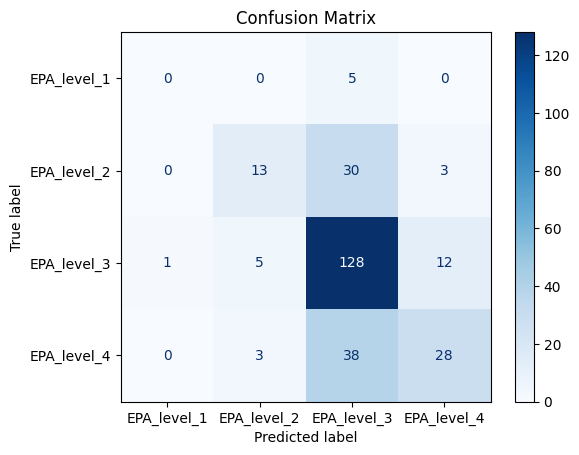

In [213]:
# Print and plot confusion matrix in numerical order
cm = confusion_matrix(y_test, y_pred, labels=epa_order)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=epa_order)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

[[  0   0  18   8]
 [  0   0 103   0]
 [  0   0  74   2]
 [  0   0  66   8]]


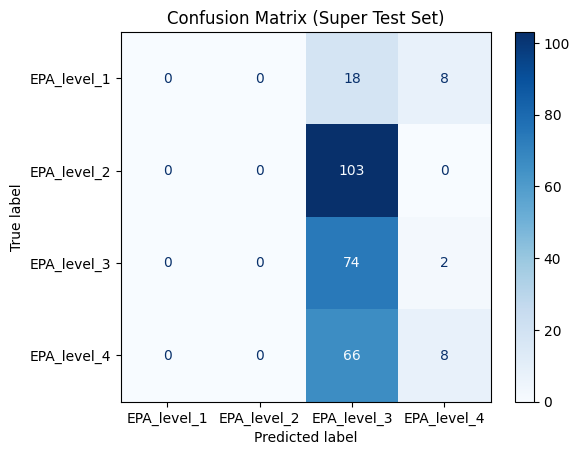

In [214]:
# Predict and evaluate on the super test set
X_super = super_test_concat[embedding_cols].select_dtypes(include=[np.number])
X_super.columns = X_super.columns.astype(str)
y_super = super_test_concat[epa_level_cols].idxmax(axis=1)

y_pred_super = rf_utub.predict(X_super)
print(confusion_matrix(y_super, y_pred_super))

# Print and plot confusion matrix in numerical order for super test set
cm_super = confusion_matrix(y_super, y_pred_super, labels=epa_order)
disp_super = ConfusionMatrixDisplay(confusion_matrix=cm_super, display_labels=epa_order)
disp_super.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix (Super Test Set)")
plt.show()

In [215]:
# Balances 4 way Random Forest Classifier
# Prepare features (X) and labels (y) as before
X = test_concat[embedding_cols].select_dtypes(include=[np.number])
X.columns = X.columns.astype(str)
y = test_concat[epa_level_cols].idxmax(axis=1)

# Set the target number of samples per class
target_count = 350
class_counts = dict(Counter(y))
sampling_strategy = {cls: min(target_count, class_counts[cls]) for cls in class_counts}
# First undersample to at most 30 per class
rus = RandomUnderSampler(sampling_strategy=sampling_strategy, random_state=15)
X_under, y_under = rus.fit_resample(X, y)

# Now oversample to exactly 30 per class
sampling_strategy = {cls: target_count for cls in class_counts}
ros = RandomOverSampler(sampling_strategy=sampling_strategy, random_state=15)
X_balanced, y_balanced = ros.fit_resample(X_under, y_under)

# Train/test split
X_train_bal, X_test_bal, y_train_bal, y_test_bal = train_test_split(
    X_balanced, y_balanced, test_size=0.2, random_state=15, stratify=y_balanced
)

# Train Random Forest
rf_bal = RandomForestClassifier(n_estimators=100, random_state=15)
rf_bal.fit(X_train_bal, y_train_bal)

# Predict and evaluate
y_pred_bal = rf_bal.predict(X_test_bal)
#print(confusion_matrix(y_test_bal, y_pred_bal))

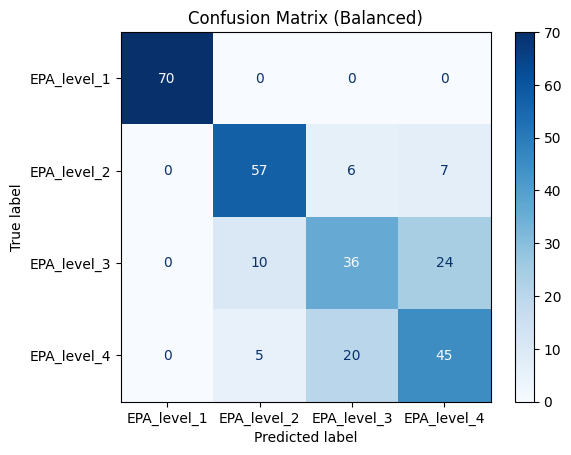

In [216]:
# Print and plot confusion matrix in numerical order
cm = confusion_matrix(y_test_bal, y_pred_bal, labels=epa_order)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=epa_order)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix (Balanced)")
plt.show()

[[ 0  2 12 12]
 [ 9  6 64 24]
 [ 0  6 42 28]
 [ 0  1 39 34]]


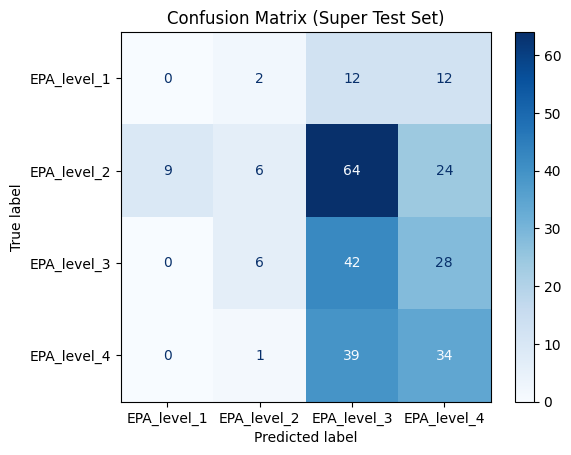

In [217]:
# Predict and evaluate on the super test set
X_super = super_test_concat[embedding_cols].select_dtypes(include=[np.number])
X_super.columns = X_super.columns.astype(str)
y_super = super_test_concat[epa_level_cols].idxmax(axis=1)

y_pred_super = rf_bal.predict(X_super)
print(confusion_matrix(y_super, y_pred_super))

# Print and plot confusion matrix in numerical order for super test set
cm_super = confusion_matrix(y_super, y_pred_super, labels=epa_order)
disp_super = ConfusionMatrixDisplay(confusion_matrix=cm_super, display_labels=epa_order)
disp_super.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix (Super Test Set)")
plt.show()

### 2 way classifiers

In [218]:
# Create new binary label
def combine_epa_levels(row):
    if row.get('EPA_level_1', 0) == 1 or row.get('EPA_level_2', 0) == 1:
        return 'EPA_level_1_2'
    elif row.get('EPA_level_4', 0) == 1:
        return 'EPA_level_4'
    else:
        return None  

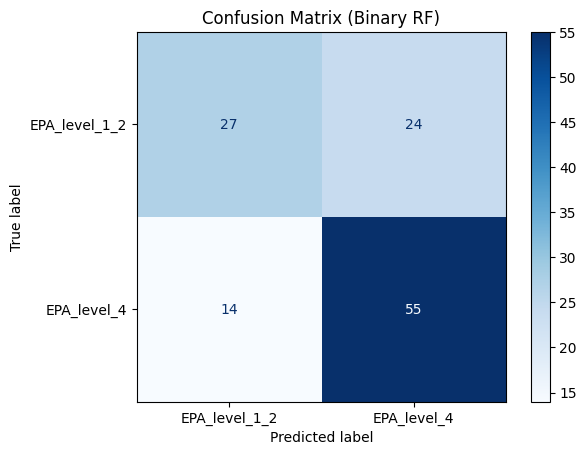

In [219]:
# Binary Classification untuned and unbalanced Random Forest Classifier
df_bin = test_concat.copy()
df_bin['EPA_binary'] = df_bin.apply(combine_epa_levels, axis=1)
df_bin = df_bin[df_bin['EPA_binary'].isin(['EPA_level_1_2', 'EPA_level_4'])].copy()

embedding_cols_bin = [
    col for col in df_bin.columns
    if col not in ['SMILES', 'SMILES_spectra', 'EPA_binary'] and not str(col).startswith('EPA_level_')
]
X_bin = df_bin[embedding_cols_bin].select_dtypes(include=[np.number])
X_bin.columns = X_bin.columns.astype(str)
y_bin = df_bin['EPA_binary']

X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(
    X_bin, y_bin, test_size=0.2, random_state=42, stratify=y_bin
)

rf_bin = RandomForestClassifier(n_estimators=100, random_state=47)
rf_bin.fit(X_train_bin, y_train_bin)
y_pred_bin = rf_bin.predict(X_test_bin)

cm_bin = confusion_matrix(y_test_bin, y_pred_bin, labels=['EPA_level_1_2', 'EPA_level_4'])
disp_bin = ConfusionMatrixDisplay(confusion_matrix=cm_bin, display_labels=['EPA_level_1_2', 'EPA_level_4'])
disp_bin.plot(cmap='Blues')
plt.title("Confusion Matrix (Binary RF)")
plt.show()

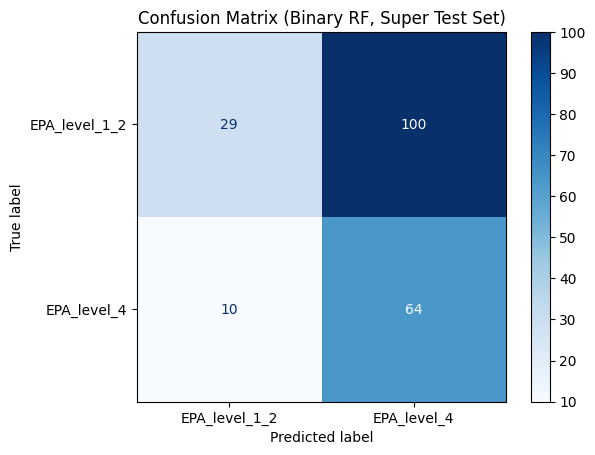

In [220]:
# Binary RF on super test set

# Recreate the binary label for the super test set
super_bin = super_test_concat.copy()
super_bin['EPA_binary'] = super_bin.apply(combine_epa_levels, axis=1)
super_bin = super_bin[super_bin['EPA_binary'].isin(['EPA_level_1_2', 'EPA_level_4'])].copy()

# Use the same embedding columns as for training
embedding_cols_bin = [
    col for col in super_bin.columns
    if col not in ['SMILES', 'SMILES_spectra', 'EPA_binary'] and not str(col).startswith('EPA_level_')
]
X_super_bin = super_bin[embedding_cols_bin].select_dtypes(include=[np.number])
X_super_bin.columns = X_super_bin.columns.astype(str)
y_super_bin = super_bin['EPA_binary']

# Predict and evaluate
y_pred_super_bin = rf_bin.predict(X_super_bin)

cm_super_bin = confusion_matrix(y_super_bin, y_pred_super_bin, labels=['EPA_level_1_2', 'EPA_level_4'])
disp_super_bin = ConfusionMatrixDisplay(confusion_matrix=cm_super_bin, display_labels=['EPA_level_1_2', 'EPA_level_4'])
disp_super_bin.plot(cmap='Blues')
plt.title("Confusion Matrix (Binary RF, Super Test Set)")
plt.show()

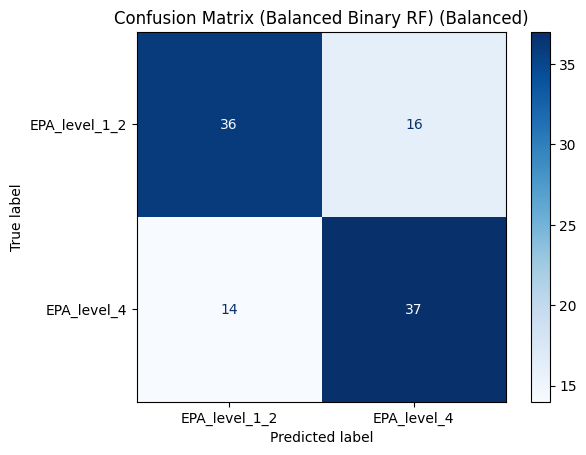

In [221]:
# Balanced Binary Classification
# Set up sampling strategy
target_count = 300
# Undersample the majority class
rus = RandomUnderSampler(sampling_strategy='auto', random_state=15)
X_under, y_under = rus.fit_resample(X_bin, y_bin)
# Oversample the minority class
ros = RandomOverSampler(sampling_strategy='auto', random_state=15)
X_bal, y_bal = ros.fit_resample(X_under, y_under)

X_train_bal, X_test_bal, y_train_bal, y_test_bal = train_test_split(
    X_bal, y_bal, test_size=0.2, random_state=15, stratify=y_bal
)

rf_bin_bal = RandomForestClassifier(n_estimators=100, random_state=15)
rf_bin_bal.fit(X_train_bal, y_train_bal)
y_pred_bal = rf_bin_bal.predict(X_test_bal)

cm_bal = confusion_matrix(y_test_bal, y_pred_bal, labels=['EPA_level_1_2', 'EPA_level_4'])
disp_bal = ConfusionMatrixDisplay(confusion_matrix=cm_bal, display_labels=['EPA_level_1_2', 'EPA_level_4'])
disp_bal.plot(cmap='Blues')
plt.title("Confusion Matrix (Balanced Binary RF) (Balanced)")
plt.show()

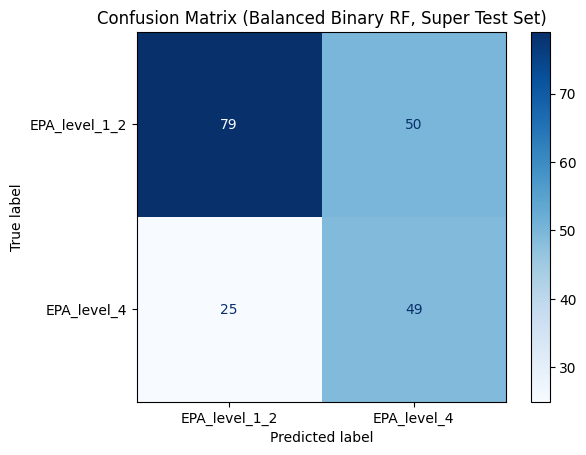

In [222]:
# Binary RF on super test set (using the balanced binary RF)

# Recreate the binary label for the super test set
super_bin = super_test_concat.copy()
super_bin['EPA_binary'] = super_bin.apply(combine_epa_levels, axis=1)
super_bin = super_bin[super_bin['EPA_binary'].isin(['EPA_level_1_2', 'EPA_level_4'])].copy()

# Use the same embedding columns as for training
embedding_cols_bin = [
    col for col in super_bin.columns
    if col not in ['SMILES', 'SMILES_spectra', 'EPA_binary'] and not str(col).startswith('EPA_level_')
]
X_super_bin = super_bin[embedding_cols_bin].select_dtypes(include=[np.number])
X_super_bin.columns = X_super_bin.columns.astype(str)
y_super_bin = super_bin['EPA_binary']

# Predict and evaluate using the balanced binary RF
y_pred_super_bin = rf_bin_bal.predict(X_super_bin)

cm_super_bin = confusion_matrix(y_super_bin, y_pred_super_bin, labels=['EPA_level_1_2', 'EPA_level_4'])
disp_super_bin = ConfusionMatrixDisplay(confusion_matrix=cm_super_bin, display_labels=['EPA_level_1_2', 'EPA_level_4'])
disp_super_bin.plot(cmap='Blues')
plt.title("Confusion Matrix (Balanced Binary RF, Super Test Set)")
plt.show()

### Three way classifiers

In [223]:
# Function to assign 3 EPA levels
def combine_epa_levels_3way(row):
    if row.get('EPA_level_1', 0) == 1 or row.get('EPA_level_2', 0) == 1:
        return 'EPA_level_1_2'
    elif row.get('EPA_level_3', 0) == 1:
        return 'EPA_level_3'
    elif row.get('EPA_level_4', 0) == 1:
        return 'EPA_level_4'
    else:
        return None

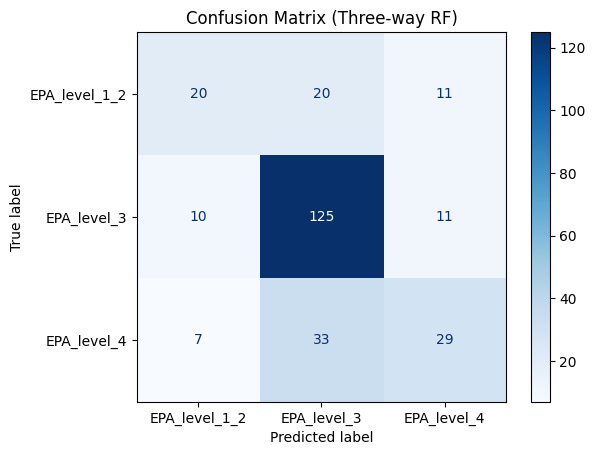

In [224]:
# Three-way classification untuned and unbalanced Random Forest Classifier
df_3way = test_concat.copy()
df_3way['EPA_3way'] = df_3way.apply(combine_epa_levels_3way, axis=1)
df_3way = df_3way[df_3way['EPA_3way'].isin(['EPA_level_1_2', 'EPA_level_3', 'EPA_level_4'])].copy()

embedding_cols_3way = [
    col for col in df_3way.columns
    if col not in ['SMILES', 'SMILES_spectra', 'EPA_3way'] and not str(col).startswith('EPA_level_')
]
X_3way = df_3way[embedding_cols_3way].select_dtypes(include=[np.number])
X_3way.columns = X_3way.columns.astype(str)
y_3way = df_3way['EPA_3way']

# Train/test split
X_train_3way, X_test_3way, y_train_3way, y_test_3way = train_test_split(
    X_3way, y_3way, test_size=0.2, random_state=42, stratify=y_3way
)

rf_3way = RandomForestClassifier(n_estimators=100, random_state=47)
rf_3way.fit(X_train_3way, y_train_3way)
y_pred_3way = rf_3way.predict(X_test_3way)

labels_3way = ['EPA_level_1_2', 'EPA_level_3', 'EPA_level_4']
cm_3way = confusion_matrix(y_test_3way, y_pred_3way, labels=labels_3way)
disp_3way = ConfusionMatrixDisplay(confusion_matrix=cm_3way, display_labels=labels_3way)
disp_3way.plot(cmap='Blues')
plt.title("Confusion Matrix (Three-way RF)")
plt.show()

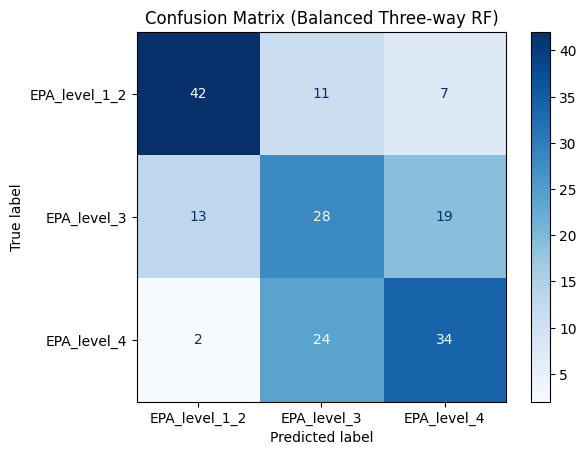

In [225]:
# Balanced Three-way Classification: EPA_level_1_2, EPA_level_3, EPA_level_4
# Set up sampling strategy
target_count = 300
class_counts_3way = dict(Counter(y_3way))
sampling_strategy_3way = {cls: min(target_count, class_counts_3way[cls]) for cls in class_counts_3way}
# Undersample the majority classes
rus_3way = RandomUnderSampler(sampling_strategy=sampling_strategy_3way, random_state=15)
X_under_3way, y_under_3way = rus_3way.fit_resample(X_3way, y_3way)
# Oversample the minority classes
sampling_strategy_3way = {cls: target_count for cls in class_counts_3way}
ros_3way = RandomOverSampler(sampling_strategy=sampling_strategy_3way, random_state=15)
X_bal_3way, y_bal_3way = ros_3way.fit_resample(X_under_3way, y_under_3way)

# Train/test split
X_train_bal_3way, X_test_bal_3way, y_train_bal_3way, y_test_bal_3way = train_test_split(
    X_bal_3way, y_bal_3way, test_size=0.2, random_state=15, stratify=y_bal_3way
)

rf_3way_bal = RandomForestClassifier(n_estimators=100, random_state=15)
rf_3way_bal.fit(X_train_bal_3way, y_train_bal_3way)
y_pred_bal_3way = rf_3way_bal.predict(X_test_bal_3way)

labels_3way = ['EPA_level_1_2', 'EPA_level_3', 'EPA_level_4']
cm_bal_3way = confusion_matrix(y_test_bal_3way, y_pred_bal_3way, labels=labels_3way)
disp_bal_3way = ConfusionMatrixDisplay(confusion_matrix=cm_bal_3way, display_labels=labels_3way)
disp_bal_3way.plot(cmap='Blues')
plt.title("Confusion Matrix (Balanced Three-way RF)")
plt.show()

### 4 way classification with grid search

Fitting 5 folds for each of 24 candidates, totalling 120 fits
[CV] END max_depth=None, max_features=sqrt, n_estimators=100; total time=   0.8s
[CV] END max_depth=None, max_features=log2, n_estimators=100; total time=   0.5s
[CV] END max_depth=None, max_features=log2, n_estimators=100; total time=   0.5s
[CV] END max_depth=None, max_features=log2, n_estimators=100; total time=   0.6s
[CV] END max_depth=None, max_features=log2, n_estimators=100; total time=   0.6s
[CV] END max_depth=None, max_features=log2, n_estimators=100; total time=   0.6s
[CV] END max_depth=None, max_features=log2, n_estimators=200; total time=   1.1s
[CV] END max_depth=None, max_features=sqrt, n_estimators=100; total time=   1.1s
[CV] END max_depth=None, max_features=sqrt, n_estimators=100; total time=   1.1s
[CV] END max_depth=None, max_features=sqrt, n_estimators=100; total time=   1.1s
[CV] END max_depth=None, max_features=sqrt, n_estimators=100; total time=   1.1s
[CV] END max_depth=None, max_features=log2, n_e

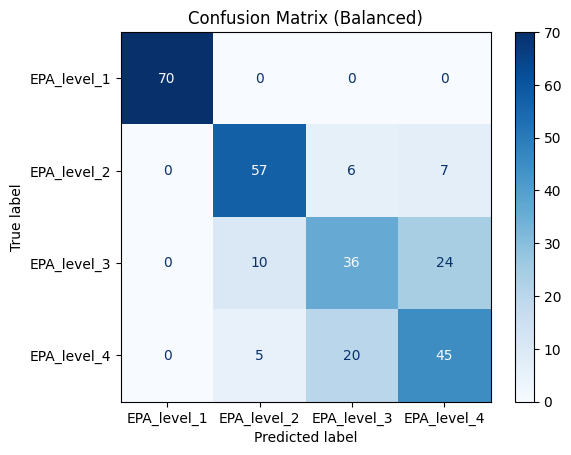

In [226]:
# Set up Random Forest and GridSearchCV for binary classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# Balances 4 way Random Forest Classifier with grid search
# Prepare features (X) and labels (y) as before
X = test_concat[embedding_cols].select_dtypes(include=[np.number])
X.columns = X.columns.astype(str)
y = test_concat[epa_level_cols].idxmax(axis=1)

# Set the target number of samples per class
target_count = 350
class_counts = dict(Counter(y))
sampling_strategy = {cls: min(target_count, class_counts[cls]) for cls in class_counts}
# First undersample to at most 30 per class
rus = RandomUnderSampler(sampling_strategy=sampling_strategy, random_state=15)
X_under, y_under = rus.fit_resample(X, y)

# Now oversample to exactly 30 per class
sampling_strategy = {cls: target_count for cls in class_counts}
ros = RandomOverSampler(sampling_strategy=sampling_strategy, random_state=15)
X_balanced, y_balanced = ros.fit_resample(X_under, y_under)

# Train/test split
X_train_bal, X_test_bal, y_train_bal, y_test_bal = train_test_split(
    X_balanced, y_balanced, test_size=0.2, random_state=15, stratify=y_balanced
)

# Train Random Forest
rf_bal = RandomForestClassifier(n_estimators=100, random_state=15)
rf_bal.fit(X_train_bal, y_train_bal)

# Predict and evaluate
y_pred_bal = rf_bal.predict(X_test_bal)
#print(confusion_matrix(y_test_bal, y_pred_bal))

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'max_features': ['sqrt', 'log2']
}

rf_bal_GS = RandomForestClassifier(random_state=47)

grid_search_bal_GS = GridSearchCV(
    estimator=rf_bal_GS,
    param_grid=param_grid,
    cv=5,
    scoring='f1_macro',  
    n_jobs=-1,
    verbose=2
)

grid_search_bal_GS.fit(X_train_bal, y_train_bal)

# Predict and evaluate
best_rf_bal_GS = grid_search_bal_GS.best_estimator_
y_pred_bal_GS = best_rf_bal_GS.predict(X_test_bal)


# Print and plot confusion matrix in numerical order
cm = confusion_matrix(y_test_bal, y_pred_bal, labels=epa_order)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=epa_order)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix (Balanced)")
plt.show()


[[ 0  3 10 13]
 [ 9  1 72 21]
 [ 0  6 45 25]
 [ 0  4 46 24]]


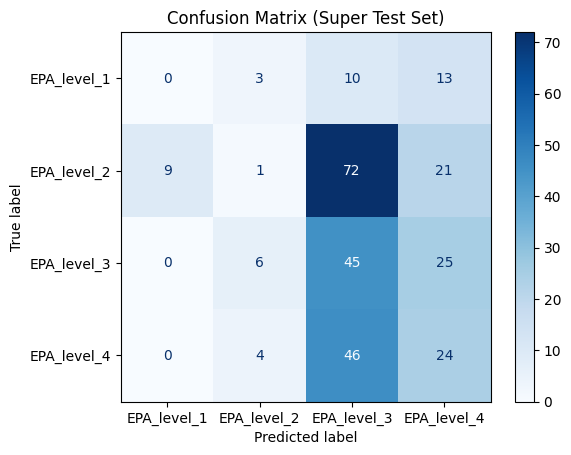

In [227]:
# Predict and evaluate on the super test set
X_super = super_test_concat[embedding_cols].select_dtypes(include=[np.number])
X_super.columns = X_super.columns.astype(str)
y_super = super_test_concat[epa_level_cols].idxmax(axis=1)

y_pred_super = best_rf_bal_GS.predict(X_super)
print(confusion_matrix(y_super, y_pred_super))

# Print and plot confusion matrix in numerical order for super test set
cm_super = confusion_matrix(y_super, y_pred_super, labels=epa_order)
disp_super = ConfusionMatrixDisplay(confusion_matrix=cm_super, display_labels=epa_order)
disp_super.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix (Super Test Set)")
plt.show()

## PCA Plots of Super Testing

In [228]:
# Functions in plotting procedure
import matplotlib.cm as cm
import matplotlib.patches as mpatches

# Isolate the embedding columns
def get_embedding_columns(df):
    # Select all columns except the first and last by index
    return df.columns[1:-2].tolist()

# Outlier removal function after PCA
def remove_outliers_on_axes(df, pc1_col, pc2_col, n_low_pc1=0, n_high_pc1=0, n_low_pc2=0, n_high_pc2=0):
    # Remove outliers on PC2
    df = df.sort_values(pc2_col, ascending=True)
    if n_low_pc2 > 0:
        df = df.iloc[n_low_pc2:]
    if n_high_pc2 > 0:
        df = df.iloc[:-n_high_pc2]
    # Remove outliers on PC1
    df = df.sort_values(pc1_col, ascending=True)
    if n_low_pc1 > 0:
        df = df.iloc[n_low_pc1:]
    if n_high_pc1 > 0:
        df = df.iloc[:-n_high_pc1]
    return df


# Outlier removal function before PCA
def remove_outliers_by_column(df, col, n_low=0, n_high=0):
    df_sorted = df.sort_values(col, ascending=True)
    if n_high > 0:
        df_sorted = df_sorted.iloc[:-n_high]
    if n_low > 0:
        df_sorted = df_sorted.iloc[n_low:]
    return df_sorted

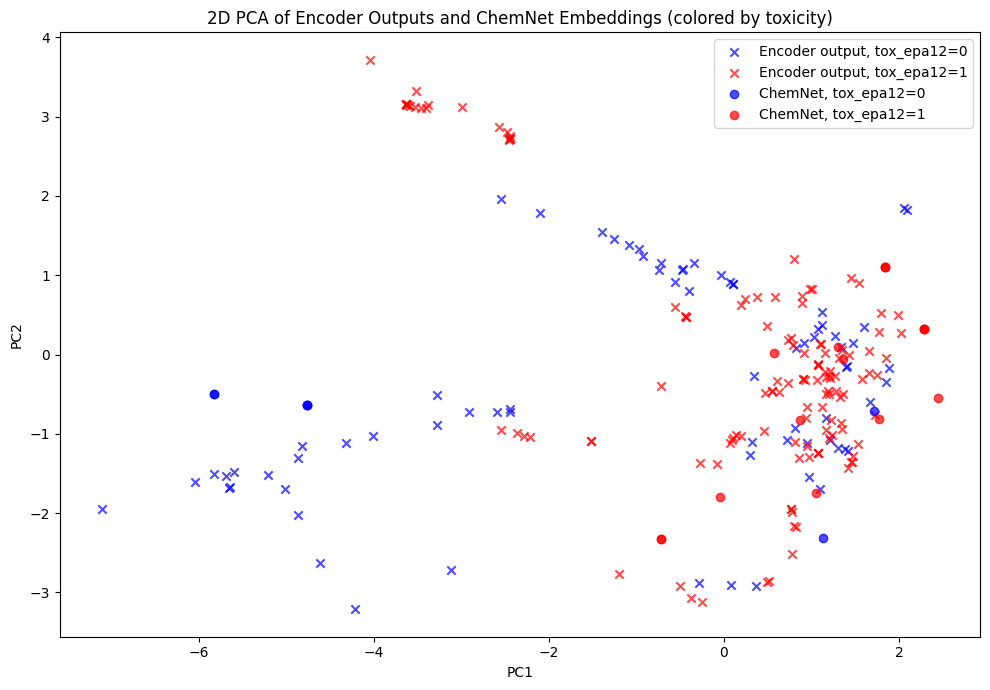

In [229]:
# Prepare encoder output data
encoder_emb_cols = [col for col in super_test_concat.columns if col.startswith('Embedding Float')]
X_encoder = super_test_concat[encoder_emb_cols].values

# Assign binary toxicity label: 1 for EPA_level_1_2, 0 for EPA_level_4, else NaN
def tox_epa12(row):
    if (row.get('EPA_level_1', 0) == 1) or (row.get('EPA_level_2', 0) == 1):
        return 1
    elif row.get('EPA_level_4', 0) == 1:
        return 0
    else:
        return np.nan

super_test_concat['tox_epa12'] = super_test_concat.apply(tox_epa12, axis=1)
tox_encoder = super_test_concat['tox_epa12'].values

# Load all ChemNet embeddings
chemnet_files = [
    "/home/dlipsey/Research/MITLincolnLabs/MIT_LL_data/ChemNet_of_df3_QQpos_no_repeats.csv",
    "/home/dlipsey/Research/MITLincolnLabs/MIT_LL_data/ChemNet_of_df3_QQneg_no_repeats.csv",
    "/home/dlipsey/Research/MITLincolnLabs/MIT_LL_data/ChemNet_of_df3_QTOFpos_no_repeats.csv",
    "/home/dlipsey/Research/MITLincolnLabs/MIT_LL_data/ChemNet_of_df3_LTQOpos_no_repeats.csv"
]
chemnet_df = pd.concat([pd.read_csv(f) for f in chemnet_files], ignore_index=True)

# Only keep SMILES present in the super test outputs
smiles_set = set(super_test_concat['SMILES_spectra'])
chemnet_df = chemnet_df[chemnet_df['SMILES'].isin(smiles_set)].copy()

# Assign toxicity label to ChemNet by matching to super_test_concat
smiles_to_tox = super_test_concat.drop_duplicates('SMILES_spectra').set_index('SMILES_spectra')['tox_epa12'].to_dict()
chemnet_df['tox_epa12'] = chemnet_df['SMILES'].map(smiles_to_tox)

# Get ChemNet embedding columns (should be all but 'SMILES' and 'tox_epa12')
chemnet_emb_cols = [col for col in chemnet_df.columns if col not in ['SMILES', 'tox_epa12']]
X_chemnet = chemnet_df[chemnet_emb_cols].values
tox_chemnet = chemnet_df['tox_epa12'].values

# PCA fit
X_all = np.vstack([X_encoder, X_chemnet])
pca = PCA(n_components=2, random_state=42)
X_all_pca = pca.fit_transform(X_all)
# Enforce consistent sign for PC1 and PC2 (optional but recommended)
if X_all_pca[:, 0].mean() < 0:
    X_all_pca[:, 0] *= -1
if X_all_pca[:, 1].mean() < 0:
    X_all_pca[:, 1] *= -1

# Re-split
X_encoder_pca = X_all_pca[:len(X_encoder)]
X_chemnet_pca = X_all_pca[len(X_encoder):]

# Plot 
plt.figure(figsize=(10,7))

# Encoder outputs 
mask_encoder_red = tox_encoder == 1
mask_encoder_blue = tox_encoder == 0
plt.scatter(X_encoder_pca[mask_encoder_blue,0], X_encoder_pca[mask_encoder_blue,1], 
            c='blue', marker='x', label='Encoder output, tox_epa12=0', alpha=0.7)
plt.scatter(X_encoder_pca[mask_encoder_red,0], X_encoder_pca[mask_encoder_red,1], 
            c='red', marker='x', label='Encoder output, tox_epa12=1', alpha=0.7)

# ChemNet points
mask_chemnet_red = tox_chemnet == 1
mask_chemnet_blue = tox_chemnet == 0
plt.scatter(X_chemnet_pca[mask_chemnet_blue,0], X_chemnet_pca[mask_chemnet_blue,1], 
            c='blue', marker='o', label='ChemNet, tox_epa12=0', alpha=0.7)
plt.scatter(X_chemnet_pca[mask_chemnet_red,0], X_chemnet_pca[mask_chemnet_red,1], 
            c='red', marker='o', label='ChemNet, tox_epa12=1', alpha=0.7)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('2D PCA of Encoder Outputs and ChemNet Embeddings (colored by toxicity)')
plt.legend()
plt.tight_layout()
plt.show()

In [230]:
super_test_concat.head()

,Embedding Float 1,Embedding Float 2,Embedding Float 3,Embedding Float 4,Embedding Float 5,Embedding Float 6,Embedding Float 7,Embedding Float 8,Embedding Float 9,Embedding Float 10,...,Embedding Float 509,Embedding Float 510,Embedding Float 511,Embedding Float 512,SMILES_spectra,EPA_level_1,EPA_level_2,EPA_level_3,EPA_level_4,tox_epa12
0,-0.118796,0.036740,0.013935,-0.281233,-0.199234,0.256752,-0.553165,-0.476637,-0.142279,-0.168028,...,-0.132766,-0.246851,-0.136751,-0.077926,C#CCN(C)Cc1ccccc1,0.0,1,0,0,1.0
1,-0.076644,0.048281,0.063377,-0.136512,-0.292297,0.393772,-0.625712,-0.462170,-0.102971,-0.136731,...,-0.111293,-0.496225,-0.213030,0.036507,C#CCN(C)Cc1ccccc1,0.0,1,0,0,1.0
2,-0.101089,0.055409,0.045409,-0.177992,-0.267050,0.364274,-0.593871,-0.481880,-0.109859,-0.151122,...,-0.060379,-0.469094,-0.208741,-0.014696,C#CCN(C)Cc1ccccc1,0.0,1,0,0,1.0
3,-0.017910,-0.008036,0.081679,0.184193,-0.170203,0.139755,-0.002426,-0.095423,0.077049,-0.201275,...,0.032792,0.164102,0.198144,-0.520441,C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1,0.0,0,1,0,NaN
4,0.076253,-0.016947,0.085805,0.239244,-0.155267,0.108971,-0.026672,-0.094393,0.087489,-0.260419,...,0.026915,0.069927,0.169451,-0.503850,C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1,0.0,0,1,0,NaN


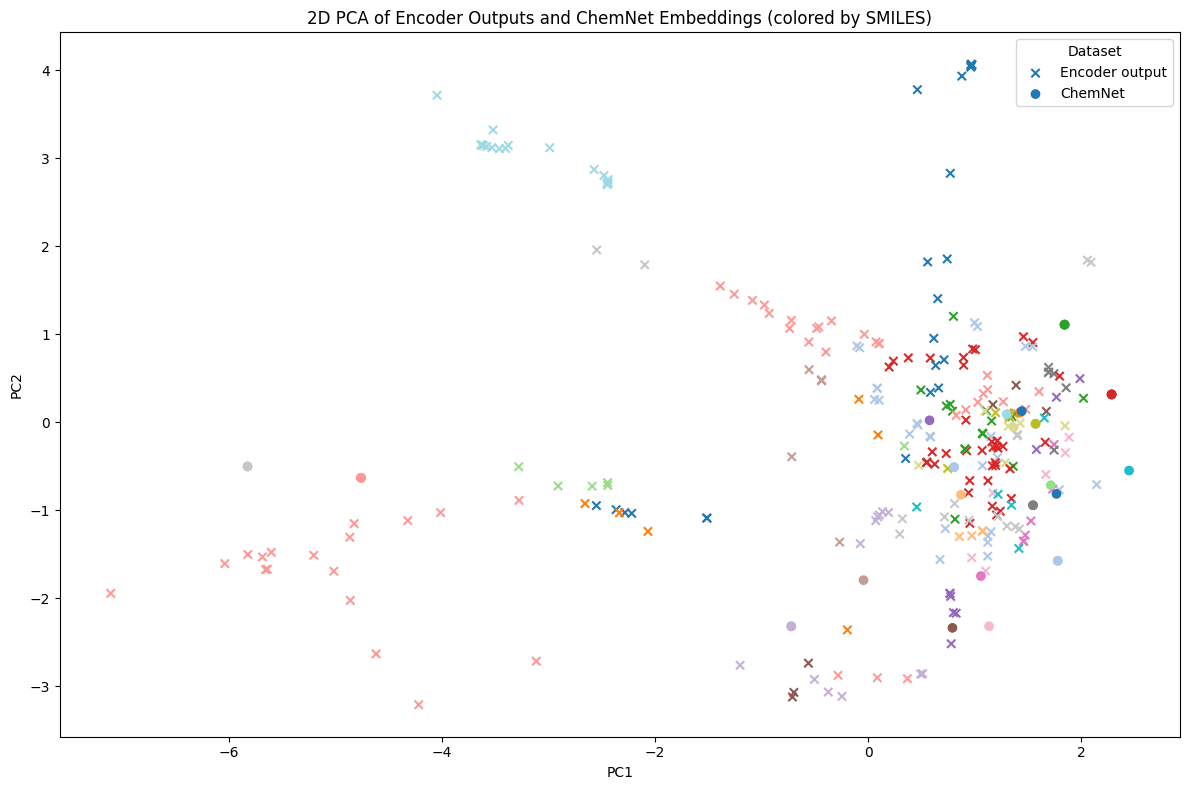

/tmp/ipykernel_861924/2344936205.py:69: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


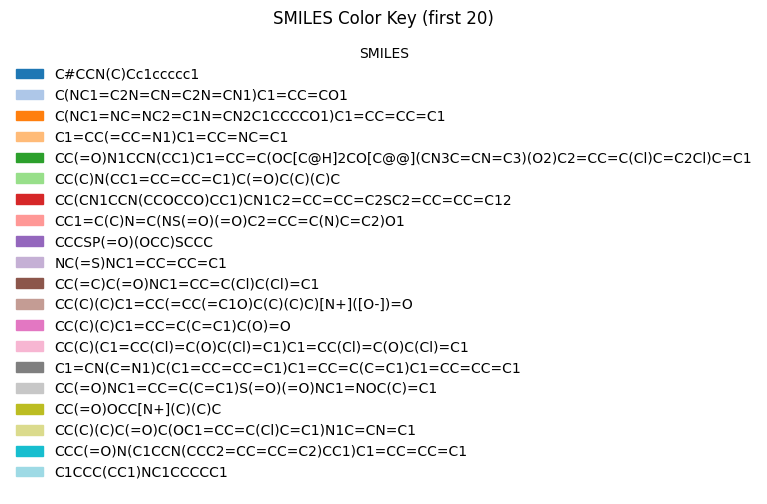

In [231]:
# PCA Plot of Super Test set, color buy SMILES
# Prepare encoder output data
encoder_emb_cols = [col for col in super_test_concat.columns if col.startswith('Embedding Float')]
X_encoder = super_test_concat[encoder_emb_cols].values

# Prepare ChemNet data
chemnet_files = [
    "/home/dlipsey/Research/MITLincolnLabs/MIT_LL_data/ChemNet_of_df3_QQpos_no_repeats.csv",
    "/home/dlipsey/Research/MITLincolnLabs/MIT_LL_data/ChemNet_of_df3_QQneg_no_repeats.csv",
    "/home/dlipsey/Research/MITLincolnLabs/MIT_LL_data/ChemNet_of_df3_QTOFpos_no_repeats.csv",
    "/home/dlipsey/Research/MITLincolnLabs/MIT_LL_data/ChemNet_of_df3_LTQOpos_no_repeats.csv"
]
chemnet_df = pd.concat([pd.read_csv(f) for f in chemnet_files], ignore_index=True)
smiles_set = set(super_test_concat['SMILES_spectra'])
chemnet_df = chemnet_df[chemnet_df['SMILES'].isin(smiles_set)].copy()

# Get ChemNet embedding columns (should be all but 'SMILES' and any label columns)
chemnet_emb_cols = [col for col in chemnet_df.columns if col not in ['SMILES', 'tox_epa12']]
X_chemnet = chemnet_df[chemnet_emb_cols].values

# PCA fit
X_all = np.vstack([X_encoder, X_chemnet])
pca = PCA(n_components=2, random_state=42)
X_all_pca = pca.fit_transform(X_all)
# Enforce consistent sign for PC1 and PC2 (optional but recommended)
if X_all_pca[:, 0].mean() < 0:
    X_all_pca[:, 0] *= -1
if X_all_pca[:, 1].mean() < 0:
    X_all_pca[:, 1] *= -1
    
# Re-split
X_encoder_pca = X_all_pca[:len(X_encoder)]
X_chemnet_pca = X_all_pca[len(X_encoder):]

# Assign colors to unique SMILES
all_smiles = pd.concat([
    super_test_concat['SMILES_spectra'],
    chemnet_df['SMILES']
]).unique()
color_map = {smiles: cm.tab20(i % 20) for i, smiles in enumerate(all_smiles)}

encoder_colors = super_test_concat['SMILES_spectra'].map(color_map)
chemnet_colors = chemnet_df['SMILES'].map(color_map)

# Plot
plt.figure(figsize=(12,8))
plt.scatter(X_encoder_pca[:,0], X_encoder_pca[:,1], 
            c=encoder_colors, marker='x', label='Encoder output', alpha=0.99)
plt.scatter(X_chemnet_pca[:,0], X_chemnet_pca[:,1], 
            c=chemnet_colors, marker='o', label='ChemNet', alpha=0.99)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('2D PCA of Encoder Outputs and ChemNet Embeddings (colored by SMILES)')
handles, labels = plt.gca().get_legend_handles_labels()
legend1 = plt.legend(handles, labels, loc='upper right', title='Dataset')
plt.tight_layout()
plt.show()

# Plot of the legend as a separate entity
plt.figure(figsize=(3, min(12, 0.3*len(all_smiles[:20]))))
max_smiles_legend = 20
smiles_legend_patches = [
    mpatches.Patch(color=color_map[smiles], label=smiles)
    for i, smiles in enumerate(all_smiles[:max_smiles_legend])
]
plt.legend(handles=smiles_legend_patches, title="SMILES", loc='center', frameon=False)
plt.axis('off')
plt.title("SMILES Color Key (first 20)")
plt.tight_layout()
plt.show()

## PCA Embeddings of combined encoders